# HVFHV Full Data EDA

This notebook re-checks the HVFHV sample EDA on the full standardized HVFHV trip files, and connects those descriptive checks to the existing full-data disruption-score outputs.

The full cleaned parquet files are not committed to GitHub. By default, this notebook expects them under `data/processed/00_standardized_trips/hvfhv/{year}/{MM}.parquet`. If your files live elsewhere, edit `PROCESSED_HVFHV_DIR_CANDIDATES` in the setup cell.

This notebook is intentionally DuckDB-first: full HVFHV data is much larger than the Yellow Taxi full-data extract, so most cells aggregate in SQL and only move summarized results into pandas.

## Notebook Map

This notebook has two blocks.

**Part I: Time Series and Temporal Structure** inspects full-data monthly trends, provider mix, daily seasonality, hourly CBD exposure, provider/shared-ride regimes, and day-of-week patterns.

**Part II: Full-Data Validation and Policy Metrics** re-checks charged versus not-charged composition, burden distribution, denominator-floor sensitivity, driver-pay outcomes, geography/OD rankings, and the precomputed DS_z vs. volume-change outputs.

## 1. Setup

This section locates the repository, finds full standardized HVFHV parquet files, configures DuckDB, and defines output folders for optional tables/figures.

In [1]:
from pathlib import Path
import os
import warnings

CWD = Path.cwd().resolve()
for candidate in [CWD, CWD.parent]:
    if (candidate / "data").exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not locate the repository root. Run this notebook from the repo root "
        "or from the notebooks/ directory."
    )

os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT / ".matplotlib-cache"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import duckdb
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook requires duckdb for full-data EDA. Install it in the active "
        "environment before running the notebook."
    ) from exc

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.4f}".format)

PROCESSED_HVFHV_DIR_CANDIDATES = [
    REPO_ROOT / "data" / "processed" / "00_standardized_trips" / "hvfhv",
    Path("/Users/ping/Desktop/data/processed/hvfhv"),
]


def parquet_files_under(root: Path) -> list[Path]:
    return sorted(root.glob("*/*.parquet"))


for candidate in PROCESSED_HVFHV_DIR_CANDIDATES:
    files = parquet_files_under(candidate)
    if files:
        PROCESSED_HVFHV_DIR = candidate
        HVFHV_FILES = files
        break
else:
    tried = "\n".join(f"  - {p}" for p in PROCESSED_HVFHV_DIR_CANDIDATES)
    raise FileNotFoundError(
        "No full standardized HVFHV parquet files found. Tried:\n"
        f"{tried}\n\n"
        "Download or regenerate the full data, or add your local directory to "
        "PROCESSED_HVFHV_DIR_CANDIDATES."
    )

FILES_2024 = [p for p in HVFHV_FILES if p.parent.name == "2024"]
FILES_2025 = [p for p in HVFHV_FILES if p.parent.name == "2025"]
if not FILES_2024 or not FILES_2025:
    raise FileNotFoundError(
        "Expected both 2024 and 2025 HVFHV parquet files under "
        f"{PROCESSED_HVFHV_DIR}."
    )

ZONE_LOOKUP_PATH = REPO_ROOT / "data" / "taxi_zone_lookup.csv"
DISRUPTION_DIR = REPO_ROOT / "data" / "processed" / "disruption_score"
TABLE_DIR = REPO_ROOT / "artifacts" / "tables"
FIGURE_DIR = REPO_ROOT / "artifacts" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_BASE_COST_FLOOR = 1.00

print(f"Repository root: {REPO_ROOT}")
print(f"HVFHV parquet directory: {PROCESSED_HVFHV_DIR}")
print(f"2024 parquet files: {len(FILES_2024)}")
print(f"2025 parquet files: {len(FILES_2025)}")
print(f"Zone lookup: {ZONE_LOOKUP_PATH}")

Repository root: /Users/qiuyue/data-science/CongestionPrice/summer26-congestion-pricing
HVFHV parquet directory: /Users/qiuyue/data-science/CongestionPrice/summer26-congestion-pricing/data/processed/00_standardized_trips/hvfhv
2024 parquet files: 5
2025 parquet files: 5
Zone lookup: /Users/qiuyue/data-science/CongestionPrice/summer26-congestion-pricing/data/taxi_zone_lookup.csv


In [2]:
def sql_path(path: Path) -> str:
    return path.resolve().as_posix().replace("'", "''")


def sql_path_list(paths: list[Path]) -> str:
    return "[" + ", ".join(f"'{sql_path(path)}'" for path in paths) + "]"


def q(sql: str) -> pd.DataFrame:
    return con.sql(sql).df()


def save_table(frame: pd.DataFrame, filename: str) -> None:
    path = TABLE_DIR / filename
    frame.to_csv(path, index=False)
    print(f"Saved table: {path.relative_to(REPO_ROOT)}")


def save_figure(filename: str) -> None:
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print(f"Saved figure: {path.relative_to(REPO_ROOT)}")


con = duckdb.connect()
# Keep AVG()/CORR() output reproducible across reruns; parallel FP sums can reorder.
con.execute("SET threads TO 1")

con.execute(
    f"""
    CREATE OR REPLACE VIEW trips_raw AS
    SELECT *
    FROM read_parquet({sql_path_list(HVFHV_FILES)}, union_by_name=true)
    """
)

schema = q("DESCRIBE trips_raw")
required_columns = {
    "year",
    "month",
    "pickup_datetime",
    "dropoff_datetime",
    "pickup_hour",
    "day_of_week",
    "PULocationID",
    "DOLocationID",
    "trip_distance_miles",
    "trip_duration_seconds",
    "cbd_congestion_fee",
    "charged_cbd_flag",
    "passenger_cost_pretip",
    "relative_cbd_burden",
    "hvfhs_license_num",
    "base_passenger_fare",
    "driver_pay",
    "shared_request_flag",
    "shared_match_flag",
}
missing_required = sorted(required_columns - set(schema["column_name"]))
if missing_required:
    raise KeyError(f"Missing expected standardized HVFHV columns: {missing_required}")

if not ZONE_LOOKUP_PATH.exists():
    raise FileNotFoundError(f"Missing taxi zone lookup: {ZONE_LOOKUP_PATH}")

con.execute(
    f"""
    CREATE OR REPLACE VIEW zone_lookup AS
    SELECT LocationID, Borough, Zone, service_zone
    FROM read_csv_auto('{sql_path(ZONE_LOOKUP_PATH)}')
    """
)

con.execute(
    f"""
    CREATE OR REPLACE VIEW trips AS
    SELECT
        *,
        CAST(pickup_datetime AS DATE) AS pickup_date_for_eda,
        trip_duration_seconds / 60.0 AS trip_duration_minutes,
        CASE hvfhs_license_num
            WHEN 'HV0003' THEN 'Uber'
            WHEN 'HV0005' THEN 'Lyft'
            WHEN 'HV0002' THEN 'Juno'
            WHEN 'HV0004' THEN 'Via'
            ELSE COALESCE(hvfhs_license_num, 'Missing')
        END AS provider_label,
        ROUND(passenger_cost_pretip - cbd_congestion_fee, 2) AS base_cost_ex_cbd,
        CASE
            WHEN charged_cbd_flag AND passenger_cost_pretip > 0
            THEN cbd_congestion_fee / passenger_cost_pretip
            ELSE NULL
        END AS relative_cbd_burden_current_cost,
        CASE
            WHEN charged_cbd_flag
             AND ROUND(passenger_cost_pretip - cbd_congestion_fee, 2) > 0
            THEN cbd_congestion_fee / ROUND(passenger_cost_pretip - cbd_congestion_fee, 2)
            ELSE NULL
        END AS relative_cbd_burden_base_cost,
        CASE
            WHEN trip_distance_miles > 0
            THEN passenger_cost_pretip / trip_distance_miles
            ELSE NULL
        END AS gross_cost_per_mile,
        CASE
            WHEN trip_distance_miles > 0
            THEN driver_pay / trip_distance_miles
            ELSE NULL
        END AS driver_pay_per_mile,
        CASE
            WHEN trip_duration_seconds > 0
            THEN driver_pay / (trip_duration_seconds / 3600.0)
            ELSE NULL
        END AS driver_pay_per_hour,
        CASE
            WHEN trip_duration_seconds > 0
            THEN trip_distance_miles / (trip_duration_seconds / 3600.0)
            ELSE NULL
        END AS speed_mph,
        CASE
            WHEN UPPER(TRIM(COALESCE(CAST(shared_request_flag AS VARCHAR), ''))) IN ('Y', 'YES', 'TRUE', '1')
            THEN TRUE ELSE FALSE
        END AS shared_request_yes_flag,
        CASE
            WHEN UPPER(TRIM(COALESCE(CAST(shared_match_flag AS VARCHAR), ''))) IN ('Y', 'YES', 'TRUE', '1')
            THEN TRUE ELSE FALSE
        END AS shared_match_yes_flag,
        airport_fee > 0 AS airport_fee_flag,
        charged_cbd_flag
            AND cbd_congestion_fee > 0
            AND ROUND(passenger_cost_pretip - cbd_congestion_fee, 2) >= {PRIMARY_BASE_COST_FLOOR:.2f}
            AS burden_floor1_flag
    FROM trips_raw
    """
)

inventory = q(
    """
    SELECT year, month, COUNT(*) AS processed_rows
    FROM trips
    GROUP BY year, month
    ORDER BY year, month
    """
)
display(inventory)

,year,month,processed_rows
0,2024,2,19352998
1,2024,3,21279860
2,2024,4,19732410
3,2024,5,20704206
4,2024,6,20122914
5,2025,2,19338054
6,2025,3,20477120
7,2025,4,19741018
8,2025,5,21090841
9,2025,6,19856429


# Part I. Time Series and Temporal Structure

This block mirrors the Yellow Taxi full-data notebook's time-series pass, adapted for HVFHV provider, shared-ride, driver-pay, and CBD-exposure fields.

## 2. Monthly Time Series: Cost, Distance, Duration, and Driver Pay

This section checks whether month-level sample findings survive on the full HVFHV population. It reports all HVFHV trips, not just fee-charged trips, so it is a broad market view.

In [3]:
monthly = q(
    """
    SELECT
        year,
        month,
        COUNT(*) AS rows,
        MEDIAN(passenger_cost_pretip) AS median_cost,
        MEDIAN(base_passenger_fare) AS median_base_fare,
        MEDIAN(driver_pay) AS median_driver_pay,
        MEDIAN(trip_distance_miles) AS median_distance,
        MEDIAN(trip_duration_minutes) AS median_duration_min,
        AVG(CASE WHEN charged_cbd_flag THEN 1.0 ELSE 0.0 END) AS charged_cbd_share,
        AVG(CASE WHEN shared_request_yes_flag THEN 1.0 ELSE 0.0 END) AS shared_request_share,
        AVG(CASE WHEN shared_match_yes_flag THEN 1.0 ELSE 0.0 END) AS shared_match_share,
        AVG(CASE WHEN airport_fee_flag THEN 1.0 ELSE 0.0 END) AS airport_fee_share
    FROM trips
    GROUP BY year, month
    ORDER BY year, month
    """
)
display(monthly)
save_table(monthly, "hvfhv_full_monthly_summary.csv")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,year,month,rows,median_cost,median_base_fare,median_driver_pay,median_distance,median_duration_min,charged_cbd_share,shared_request_share,shared_match_share,airport_fee_share
0,2024,2,19352998,21.9100,18.5200,14.4600,2.9200,15.7667,0.0000,0.0376,0.0130,0.0769
1,2024,3,21279860,22.7600,19.2400,14.5300,2.9180,15.9500,0.0000,0.0379,0.0136,0.0803
2,2024,4,19732410,22.8600,19.3400,14.7700,2.9800,16.1500,0.0000,0.0384,0.0138,0.0853
3,2024,5,20704206,23.8000,20.1500,15.4600,3.0500,16.8500,0.0000,0.0372,0.0137,0.0912
4,2024,6,20122914,23.7500,20.1100,15.4800,3.1000,16.6833,0.0000,0.0360,0.0141,0.0876
5,2025,2,19338054,22.8000,18.8500,14.3400,2.8800,15.5333,0.3530,0.0365,0.0197,0.0771
6,2025,3,20477120,24.6900,20.6300,15.2000,2.9500,15.7167,0.3434,0.0278,0.0146,0.0843
7,2025,4,19741018,22.9900,19.1400,15.1500,2.9800,16.0500,0.3509,0.0274,0.0151,0.0840
8,2025,5,21090841,23.9700,19.9900,16.1200,3.0200,16.6000,0.3433,0.0299,0.0171,0.0897
9,2025,6,19856429,23.9500,20.0200,16.0600,3.0400,16.3333,0.3371,0.0316,0.0185,0.0905


Saved table: artifacts/tables/hvfhv_full_monthly_summary.csv


,month,median_cost_diff_2025_minus_2024,median_cost_pct_change_2025_vs_2024,median_base_fare_diff_2025_minus_2024,median_base_fare_pct_change_2025_vs_2024,median_driver_pay_diff_2025_minus_2024,median_driver_pay_pct_change_2025_vs_2024,median_distance_diff_2025_minus_2024,median_distance_pct_change_2025_vs_2024,median_duration_min_diff_2025_minus_2024,median_duration_min_pct_change_2025_vs_2024,row_count_pct_change_2025_vs_2024
0,2,0.8900,4.0621,0.3300,1.7819,-0.1200,-0.8299,-0.0400,-1.3699,-0.2333,-1.4799,-0.0772
1,3,1.9300,8.4798,1.3900,7.2245,0.6700,4.6111,0.0320,1.0966,-0.2333,-1.4629,-3.7723
2,4,0.1300,0.5687,-0.2000,-1.0341,0.3800,2.5728,0.0000,0.0000,-0.1000,-0.6192,0.0436
3,5,0.1700,0.7143,-0.1600,-0.7940,0.6600,4.2691,-0.0300,-0.9836,-0.2500,-1.4837,1.8674
4,6,0.2000,0.8421,-0.0900,-0.4475,0.5800,3.7468,-0.0600,-1.9355,-0.3500,-2.0979,-1.3243


Saved table: artifacts/tables/hvfhv_full_monthly_yoy.csv
Saved figure: artifacts/figures/hvfhv_full_monthly_core_metrics.png


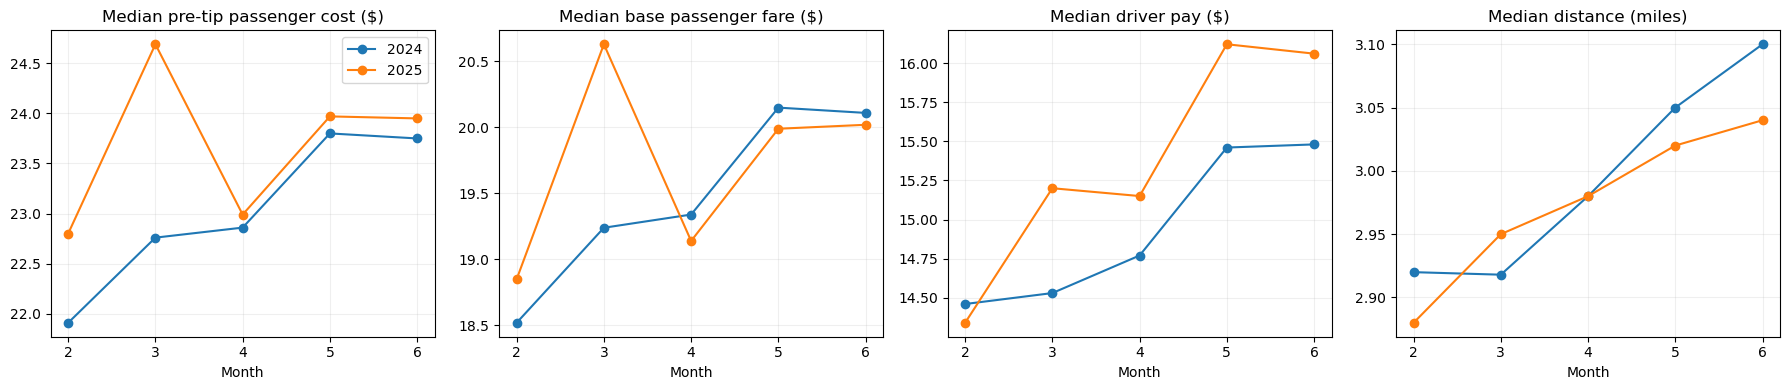

In [4]:
monthly_pivot = monthly.pivot(
    index="month",
    columns="year",
    values=["rows", "median_cost", "median_base_fare", "median_driver_pay", "median_distance", "median_duration_min"],
)

yoy_rows = []
for month in sorted(monthly["month"].unique()):
    row = {"month": month}
    for metric in ["median_cost", "median_base_fare", "median_driver_pay", "median_distance", "median_duration_min"]:
        row[f"{metric}_diff_2025_minus_2024"] = (
            monthly_pivot[(metric, 2025)].loc[month] - monthly_pivot[(metric, 2024)].loc[month]
        )
        row[f"{metric}_pct_change_2025_vs_2024"] = 100 * (
            monthly_pivot[(metric, 2025)].loc[month] / monthly_pivot[(metric, 2024)].loc[month] - 1
        )
    row["row_count_pct_change_2025_vs_2024"] = 100 * (
        monthly_pivot[("rows", 2025)].loc[month] / monthly_pivot[("rows", 2024)].loc[month] - 1
    )
    yoy_rows.append(row)

yoy_monthly = pd.DataFrame(yoy_rows)
display(yoy_monthly)
save_table(yoy_monthly, "hvfhv_full_monthly_yoy.csv")

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True)
plot_specs = [
    ("median_cost", "Median pre-tip passenger cost ($)"),
    ("median_base_fare", "Median base passenger fare ($)"),
    ("median_driver_pay", "Median driver pay ($)"),
    ("median_distance", "Median distance (miles)"),
]
for ax, (col, title) in zip(axes, plot_specs):
    for year in [2024, 2025]:
        g = monthly[monthly["year"] == year]
        ax.plot(g["month"], g[col], marker="o", label=str(year))
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_xticks([2, 3, 4, 5, 6])
    ax.grid(alpha=0.2)
axes[0].legend()
save_figure("hvfhv_full_monthly_core_metrics.png")
plt.show()

**Reading guide:** compare 2025 against the same month in 2024. A broad increase in `passenger_cost_pretip` should be separated from the flat CBD fee itself; `base_passenger_fare` and `driver_pay` help distinguish fare-level changes from fee pass-through.

## 3. Trip Volume and Provider Mix

HVFHV volume should be interpreted together with provider mix. A total-volume shift can reflect market-share changes between Uber, Lyft, and smaller providers, not only congestion-pricing response.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,year,month,provider_label,rows,provider_share
0,2024,2,Uber,14403218,0.7442
1,2024,2,Lyft,4949780,0.2558
2,2024,3,Uber,15621152,0.7341
3,2024,3,Lyft,5658708,0.2659
4,2024,4,Uber,14703642,0.7452
5,2024,4,Lyft,5028768,0.2548
6,2024,5,Uber,15537995,0.7505
7,2024,5,Lyft,5166211,0.2495
8,2024,6,Uber,15157774,0.7533
9,2024,6,Lyft,4965140,0.2467


Saved table: artifacts/tables/hvfhv_full_provider_month.csv
Saved figure: artifacts/figures/hvfhv_full_volume_and_provider_mix.png


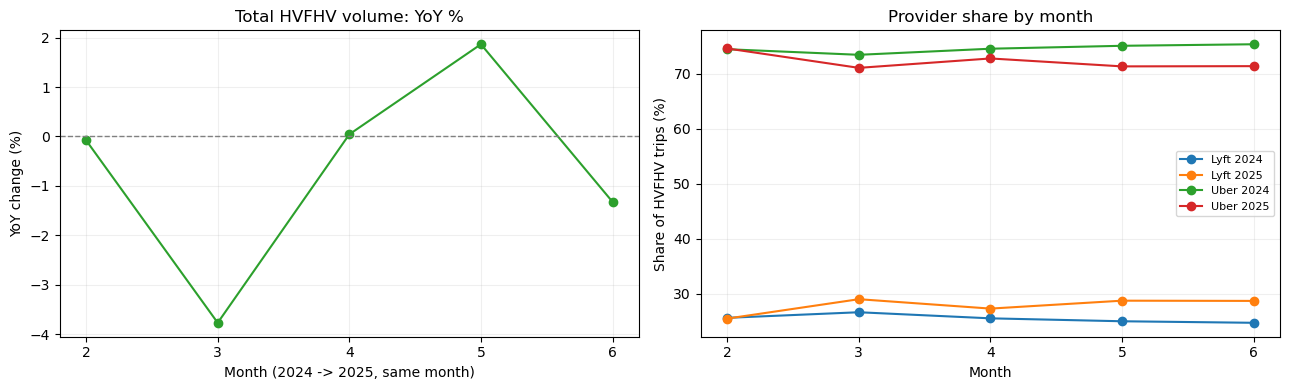

In [5]:
provider_month = q(
    """
    SELECT
        year,
        month,
        provider_label,
        COUNT(*) AS rows,
        COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY year, month) AS provider_share
    FROM trips
    GROUP BY year, month, provider_label
    ORDER BY year, month, rows DESC
    """
)
display(provider_month.head(20))
save_table(provider_month, "hvfhv_full_provider_month.csv")

vol_pivot = monthly.pivot(index="month", columns="year", values="rows")
vol_yoy = 100 * (vol_pivot[2025] / vol_pivot[2024] - 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(vol_yoy.index, vol_yoy.values, marker="o", color="tab:green")
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Total HVFHV volume: YoY %")
axes[0].set_xlabel("Month (2024 -> 2025, same month)")
axes[0].set_ylabel("YoY change (%)")
axes[0].set_xticks([2, 3, 4, 5, 6])
axes[0].grid(alpha=0.2)

for provider, g in provider_month[provider_month["provider_label"].isin(["Uber", "Lyft"])].groupby("provider_label"):
    for year, gy in g.groupby("year"):
        axes[1].plot(
            gy["month"],
            100 * gy["provider_share"],
            marker="o",
            label=f"{provider} {year}",
        )
axes[1].set_title("Provider share by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Share of HVFHV trips (%)")
axes[1].set_xticks([2, 3, 4, 5, 6])
axes[1].grid(alpha=0.2)
axes[1].legend(fontsize=8)
save_figure("hvfhv_full_volume_and_provider_mix.png")
plt.show()

## 4. Daily Lag Structure and Weekly Seasonality

This mirrors the Yellow Taxi notebook's lag diagnostics. The goal is to see whether daily HVFHV volume and cost are dominated by day-of-week seasonality, short-run persistence, or isolated holidays.

In [6]:
daily_ts = q(
    """
    SELECT
        year,
        pickup_date_for_eda AS pickup_date,
        COUNT(*) AS trip_count,
        MEDIAN(passenger_cost_pretip) AS median_cost,
        MEDIAN(driver_pay) AS median_driver_pay,
        MEDIAN(trip_distance_miles) AS median_distance
    FROM trips
    GROUP BY year, pickup_date_for_eda
    ORDER BY year, pickup_date_for_eda
    """
)
daily_ts["pickup_date"] = pd.to_datetime(daily_ts["pickup_date"])

for col in ["trip_count", "median_cost", "median_driver_pay"]:
    daily_ts[f"{col}_lag1"] = daily_ts.groupby("year")[col].shift(1)
    daily_ts[f"{col}_lag7"] = daily_ts.groupby("year")[col].shift(7)

display(daily_ts.head(10))
save_table(daily_ts, "hvfhv_full_daily_timeseries.csv")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,year,pickup_date,trip_count,median_cost,median_driver_pay,median_distance,trip_count_lag1,trip_count_lag7,median_cost_lag1,median_cost_lag7,median_driver_pay_lag1,median_driver_pay_lag7
0,2024,2024-02-01,646805,21.9900,14.0300,2.8610,NaN,NaN,NaN,NaN,NaN,NaN
1,2024,2024-02-02,743190,21.4600,13.6200,2.7600,"646,805.0000",NaN,21.9900,NaN,14.0300,NaN
2,2024,2024-02-03,780641,21.8500,13.9300,2.9300,"743,190.0000",NaN,21.4600,NaN,13.6200,NaN
3,2024,2024-02-04,646833,21.8900,13.8600,3.2000,"780,641.0000",NaN,21.8500,NaN,13.9300,NaN
4,2024,2024-02-05,562370,20.9600,15.8200,2.8500,"646,833.0000",NaN,21.8900,NaN,13.8600,NaN
5,2024,2024-02-06,586637,21.7700,16.1400,2.7600,"562,370.0000",NaN,20.9600,NaN,15.8200,NaN
6,2024,2024-02-07,605037,21.9700,16.4800,2.8200,"586,637.0000",NaN,21.7700,NaN,16.1400,NaN
7,2024,2024-02-08,655744,22.7400,16.7500,2.9100,"605,037.0000","646,805.0000",21.9700,21.9900,16.4800,14.0300
8,2024,2024-02-09,739207,21.9600,16.6000,2.9200,"655,744.0000","743,190.0000",22.7400,21.4600,16.7500,13.6200
9,2024,2024-02-10,777753,22.3600,16.7500,3.0700,"739,207.0000","780,641.0000",21.9600,21.8500,16.6000,13.9300


Saved table: artifacts/tables/hvfhv_full_daily_timeseries.csv


,year,variable,lag1_corr,lag7_corr
0,2024,trip_count,0.4640,0.8250
1,2024,median_cost,0.6981,0.5694
2,2024,median_driver_pay,0.6918,0.2148
3,2025,trip_count,0.5096,0.8600
4,2025,median_cost,0.7496,0.2314
5,2025,median_driver_pay,0.7663,0.4613


Saved table: artifacts/tables/hvfhv_full_lag_correlation_summary.csv
Saved figure: artifacts/figures/hvfhv_full_daily_rolling_metrics.png


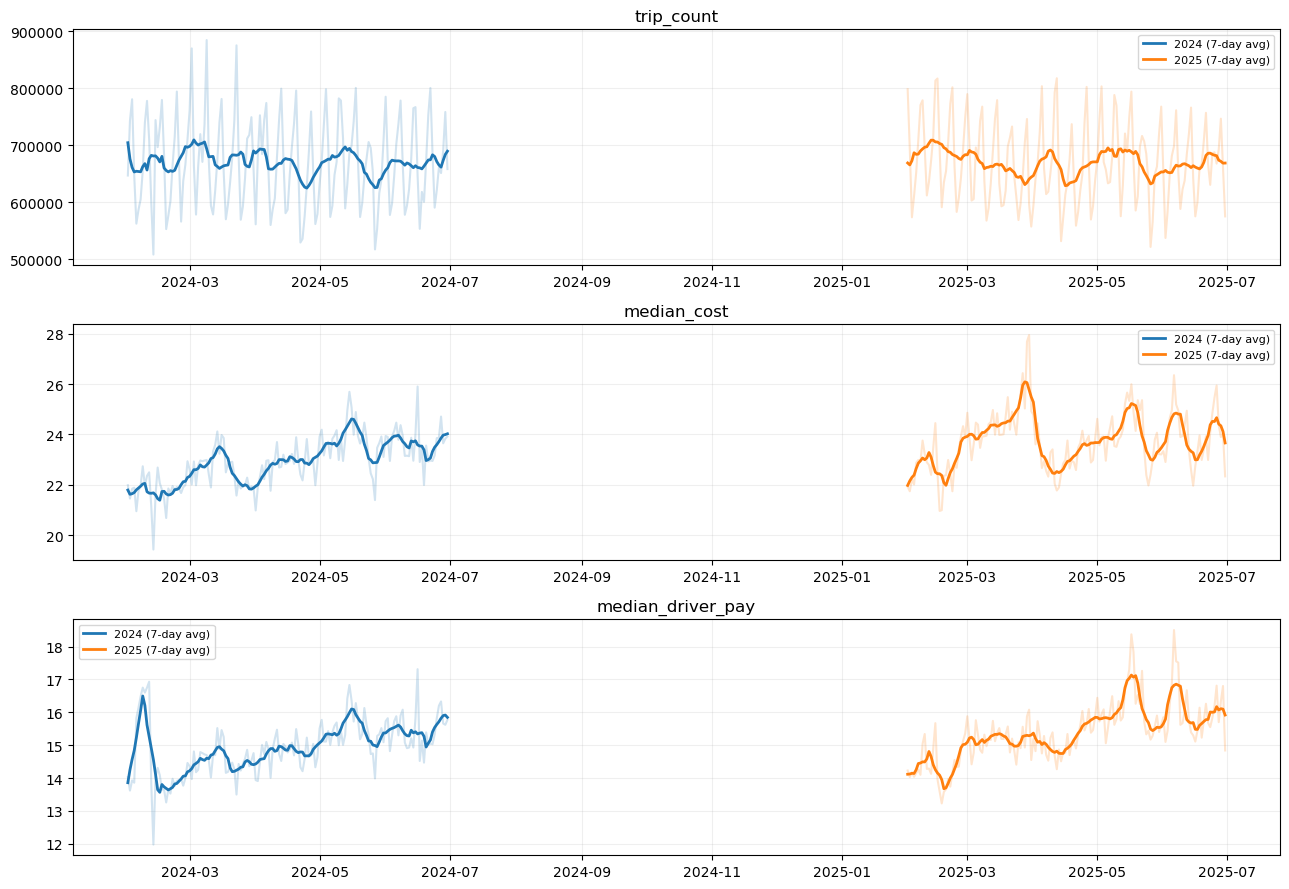

In [7]:
lag_correlations = []
for year, g in daily_ts.groupby("year"):
    for var in ["trip_count", "median_cost", "median_driver_pay"]:
        lag_correlations.append({
            "year": year,
            "variable": var,
            "lag1_corr": g[[var, f"{var}_lag1"]].corr().iloc[0, 1],
            "lag7_corr": g[[var, f"{var}_lag7"]].corr().iloc[0, 1],
        })
lag_correlation_summary = pd.DataFrame(lag_correlations)
display(lag_correlation_summary)
save_table(lag_correlation_summary, "hvfhv_full_lag_correlation_summary.csv")

roll_vars = ["trip_count", "median_cost", "median_driver_pay"]
dts = daily_ts.copy()
for col in roll_vars:
    dts[f"{col}_roll7"] = dts.groupby("year")[col].transform(
        lambda s: s.rolling(7, center=True, min_periods=1).mean()
    )

fig, axes = plt.subplots(len(roll_vars), 1, figsize=(13, 9), sharex=False)
for ax, col in zip(axes, roll_vars):
    for year in [2024, 2025]:
        g = dts[dts["year"] == year].sort_values("pickup_date")
        base = ax.plot(g["pickup_date"], g[col], alpha=0.20)[0]
        ax.plot(g["pickup_date"], g[f"{col}_roll7"], linewidth=2, color=base.get_color(), label=f"{year} (7-day avg)")
    ax.set_title(col)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
save_figure("hvfhv_full_daily_rolling_metrics.png")
plt.show()

Saved figure: artifacts/figures/hvfhv_full_stl_trip_count.png


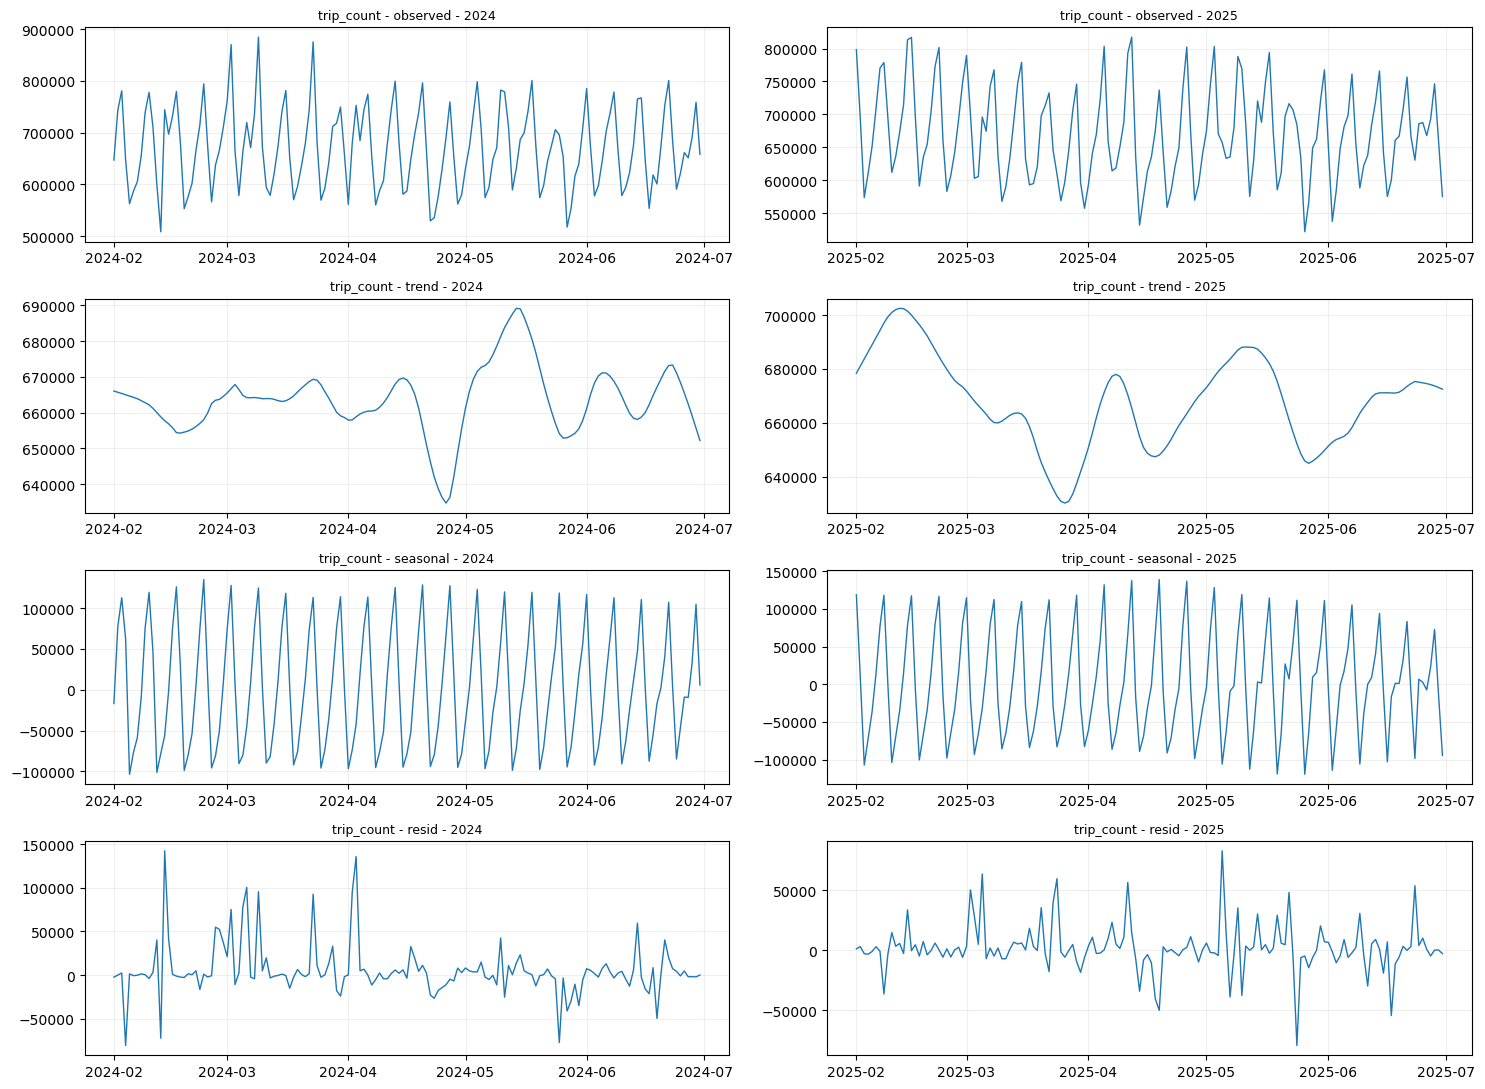

In [8]:
try:
    from statsmodels.tsa.seasonal import STL

    stl_var = "trip_count"
    fig, axes = plt.subplots(4, 2, figsize=(15, 11))
    for col_idx, year in enumerate([2024, 2025]):
        g = daily_ts[daily_ts["year"] == year].set_index("pickup_date").sort_index()
        series = g[stl_var].asfreq("D").interpolate()
        res = STL(series, period=7, robust=True).fit()
        components = [
            ("observed", res.observed),
            ("trend", res.trend),
            ("seasonal", res.seasonal),
            ("resid", res.resid),
        ]
        for row, (name, comp) in enumerate(components):
            ax = axes[row, col_idx]
            ax.plot(comp.index, comp.values, linewidth=1)
            ax.set_title(f"{stl_var} - {name} - {year}", fontsize=9)
            ax.grid(alpha=0.2)
    save_figure("hvfhv_full_stl_trip_count.png")
    plt.show()
except Exception as exc:
    print(f"STL decomposition skipped: {exc}")

## 5. Time-of-Day CBD Exposure

This checks whether CBD charging varies by pickup hour in the full 2025 HVFHV data, and whether burden, passenger cost, and driver pay move differently across the day.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,pickup_hour,rows,charged_cbd_share,median_current_cost_burden_charged,median_base_cost_burden_floor1,median_cost,median_driver_pay,median_distance
0,0,3583991,0.3720,0.0419,0.0437,23.9500,15.5100,3.4060
1,1,2487721,0.3902,0.0441,0.0462,23.4300,14.8700,3.3800
2,2,1763595,0.3943,0.0444,0.0465,23.7400,14.9800,3.5300
3,3,1433395,0.3670,0.0412,0.0429,25.5100,16.2100,4.0800
4,4,1511676,0.3240,0.0315,0.0325,29.8900,19.1000,5.1000
5,5,1823712,0.3079,0.0320,0.0331,27.9000,18.3900,5.1220
6,6,2833477,0.3018,0.0399,0.0415,24.6700,16.4500,4.0400
7,7,4238075,0.2763,0.0419,0.0438,23.7400,15.4500,3.0600
8,8,5217481,0.2944,0.0417,0.0435,22.8000,14.6700,2.6600
9,9,4879393,0.3233,0.0435,0.0455,22.4100,14.3000,2.7200


Saved table: artifacts/tables/hvfhv_full_hourly_2025.csv
Saved figure: artifacts/figures/hvfhv_full_hourly_2025_panel.png


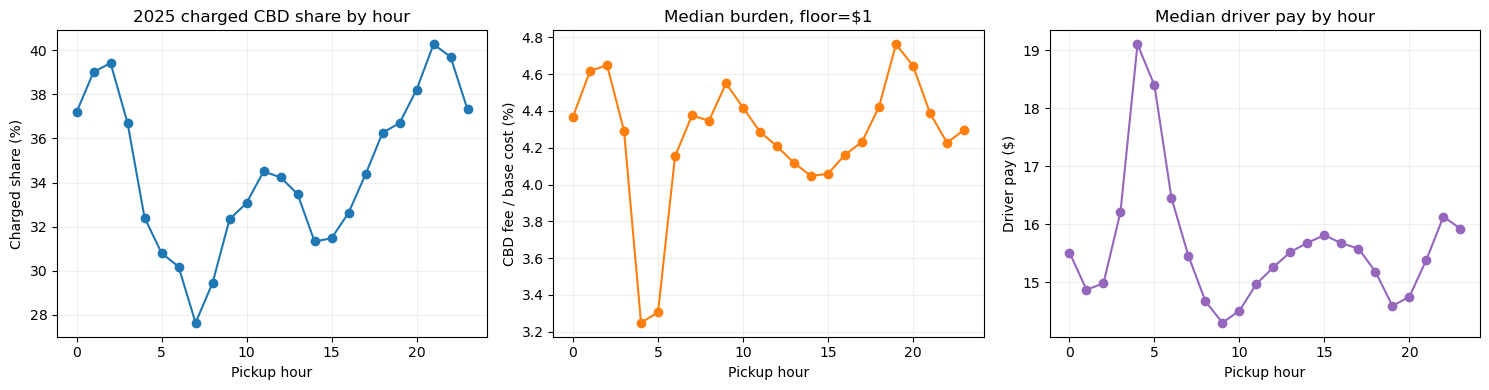

In [9]:
hourly_2025 = q(
    """
    SELECT
        pickup_hour,
        COUNT(*) AS rows,
        AVG(CASE WHEN charged_cbd_flag THEN 1.0 ELSE 0.0 END) AS charged_cbd_share,
        MEDIAN(CASE WHEN charged_cbd_flag THEN relative_cbd_burden_current_cost ELSE NULL END) AS median_current_cost_burden_charged,
        MEDIAN(CASE WHEN burden_floor1_flag THEN relative_cbd_burden_base_cost ELSE NULL END) AS median_base_cost_burden_floor1,
        MEDIAN(passenger_cost_pretip) AS median_cost,
        MEDIAN(driver_pay) AS median_driver_pay,
        MEDIAN(trip_distance_miles) AS median_distance
    FROM trips
    WHERE year = 2025
    GROUP BY pickup_hour
    ORDER BY pickup_hour
    """
)
display(hourly_2025)
save_table(hourly_2025, "hvfhv_full_hourly_2025.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hourly_2025["pickup_hour"], 100 * hourly_2025["charged_cbd_share"], marker="o")
axes[0].set_title("2025 charged CBD share by hour")
axes[0].set_ylabel("Charged share (%)")
axes[1].plot(hourly_2025["pickup_hour"], 100 * hourly_2025["median_base_cost_burden_floor1"], marker="o", color="tab:orange")
axes[1].set_title("Median burden, floor=$1")
axes[1].set_ylabel("CBD fee / base cost (%)")
axes[2].plot(hourly_2025["pickup_hour"], hourly_2025["median_driver_pay"], marker="o", color="tab:purple")
axes[2].set_title("Median driver pay by hour")
axes[2].set_ylabel("Driver pay ($)")
for ax in axes:
    ax.set_xlabel("Pickup hour")
    ax.grid(alpha=0.2)
save_figure("hvfhv_full_hourly_2025_panel.png")
plt.show()

## 6. Provider and Shared-Ride Regimes

Yellow Taxi has payment regimes; HVFHV has provider and shared-ride regimes. This section checks whether provider composition, shared requests, and shared matches differ by year and whether they need to be carried as descriptive controls.

For passenger burden, the main tables keep the TLC row as the unit of analysis because each row is a rider trip. For congestion/vehicle-volume interpretation, matched shared rides need a caveat: multiple passenger records can correspond to the same vehicle movement. The distance-controlled diagnostic below checks whether shared rows are materially different enough to require a sensitivity run that drops them from vehicle-volume summaries.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,year,provider_label,rows,charged_cbd_share,shared_request_share,shared_match_share,median_cost,median_base_fare,median_driver_pay,median_distance
0,2024,Uber,75423781,0.0000,0.0502,0.0183,22.8500,19.3300,15.0100,2.9900
1,2024,Lyft,25768607,0.0000,0.0000,0.0001,23.6400,19.8400,14.6900,3.0180
2,2025,Uber,72529617,0.3400,0.0424,0.0234,23.9400,20.0000,15.4800,2.9700
3,2025,Lyft,27973845,0.3595,0.0000,0.0002,22.9900,19.1100,15.1200,2.9970


Saved table: artifacts/tables/hvfhv_full_provider_summary.csv
Saved figure: artifacts/figures/hvfhv_full_provider_summary.png


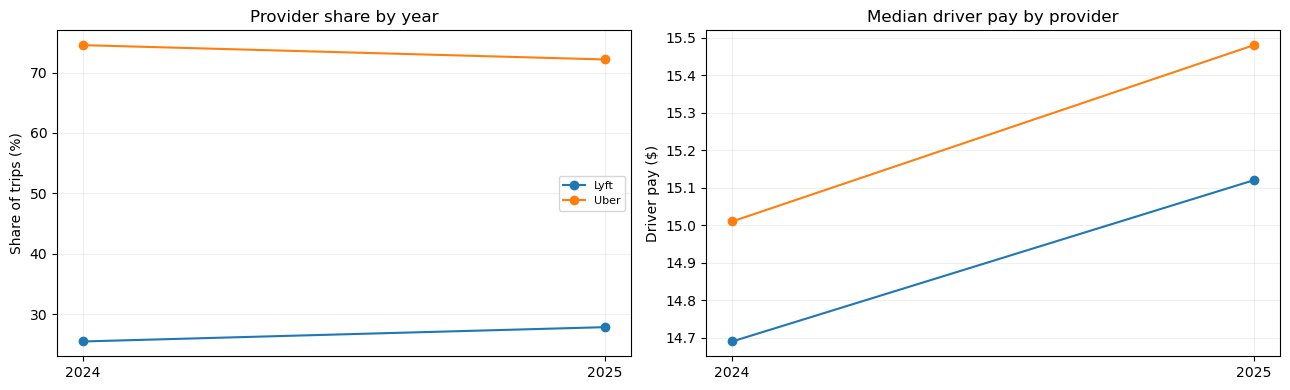

In [10]:
provider_summary = q(
    """
    SELECT
        year,
        provider_label,
        COUNT(*) AS rows,
        AVG(CASE WHEN charged_cbd_flag THEN 1.0 ELSE 0.0 END) AS charged_cbd_share,
        AVG(CASE WHEN shared_request_yes_flag THEN 1.0 ELSE 0.0 END) AS shared_request_share,
        AVG(CASE WHEN shared_match_yes_flag THEN 1.0 ELSE 0.0 END) AS shared_match_share,
        MEDIAN(passenger_cost_pretip) AS median_cost,
        MEDIAN(base_passenger_fare) AS median_base_fare,
        MEDIAN(driver_pay) AS median_driver_pay,
        MEDIAN(trip_distance_miles) AS median_distance
    FROM trips
    GROUP BY year, provider_label
    ORDER BY year, rows DESC
    """
)
display(provider_summary)
save_table(provider_summary, "hvfhv_full_provider_summary.csv")

provider_share = provider_summary.copy()
provider_share["provider_share"] = provider_share["rows"] / provider_share.groupby("year")["rows"].transform("sum")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for provider, g in provider_share.groupby("provider_label"):
    axes[0].plot(g["year"], 100 * g["provider_share"], marker="o", label=provider)
axes[0].set_title("Provider share by year")
axes[0].set_xticks([2024, 2025])
axes[0].set_ylabel("Share of trips (%)")
axes[0].grid(alpha=0.2)
axes[0].legend(fontsize=8)

for provider, g in provider_summary.groupby("provider_label"):
    axes[1].plot(g["year"], g["median_driver_pay"], marker="o", label=provider)
axes[1].set_title("Median driver pay by provider")
axes[1].set_xticks([2024, 2025])
axes[1].set_ylabel("Driver pay ($)")
axes[1].grid(alpha=0.2)
save_figure("hvfhv_full_provider_summary.png")
plt.show()

In [11]:
shared_summary = q(
    """
    SELECT
        year,
        shared_request_yes_flag,
        shared_match_yes_flag,
        COUNT(*) AS rows,
        AVG(CASE WHEN charged_cbd_flag THEN 1.0 ELSE 0.0 END) AS charged_cbd_share,
        MEDIAN(passenger_cost_pretip) AS median_cost,
        MEDIAN(driver_pay) AS median_driver_pay,
        MEDIAN(trip_distance_miles) AS median_distance,
        MEDIAN(trip_duration_minutes) AS median_duration_min
    FROM trips
    GROUP BY year, shared_request_yes_flag, shared_match_yes_flag
    ORDER BY year, shared_request_yes_flag DESC, shared_match_yes_flag DESC
    """
)
display(shared_summary)
save_table(shared_summary, "hvfhv_full_shared_ride_summary.csv")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,year,shared_request_yes_flag,shared_match_yes_flag,rows,charged_cbd_share,median_cost,median_driver_pay,median_distance,median_duration_min
0,2024,True,True,1378651,0.0000,21.3700,15.1700,5.4600,26.4667
1,2024,True,False,2407553,0.0000,16.3000,12.4600,2.7000,13.5500
2,2024,False,True,1848,0.0000,21.8500,11.9000,2.1410,13.5333
3,2024,False,False,97404336,0.0000,22.9900,15.0000,2.9700,16.2333
4,2025,True,True,1700009,0.2664,21.6700,16.5100,5.7400,26.2500
5,2025,True,False,1373877,0.1461,14.5800,12.3700,2.6400,12.8833
6,2025,False,True,5264,0.6005,27.9950,14.1450,2.4130,14.9500
7,2025,False,False,97424312,0.3496,23.9300,15.4000,2.9400,15.9500


Saved table: artifacts/tables/hvfhv_full_shared_ride_summary.csv


### Distance-Controlled Shared-Ride Diagnostic

This table compares shared and non-shared HVFHV rows within the same distance bucket. It is a sensitivity diagnostic, not a replacement for the main row-level burden tables: rider-burden metrics remain passenger-trip based, while matched shared rows are flagged as a possible overcount for vehicle-volume/congestion interpretations.


,distance_bucket,bucket_order,shared_ride_regime,rows,row_share_within_distance_bucket,charged_cbd_share,median_cost,median_base_fare,median_driver_pay,median_duration_min,median_base_cost_burden_floor1,median_cost_gap_vs_not_shared,median_base_fare_gap_vs_not_shared,median_burden_gap_vs_not_shared
0,"(0,1]",1,not_shared,10919918,0.9831,0.2515,10.1400,8.9400,5.2500,5.6000,0.0952,0.0000,0.0000,0.0000
1,"(0,1]",1,requested_unmatched,159827,0.0144,0.1378,8.2000,7.2900,4.5700,4.9000,0.1371,-1.9400,-1.6500,0.0419
2,"(0,1]",1,matched_shared,26870,0.0024,0.2139,8.5800,7.5600,3.2000,5.4833,0.1365,-1.5600,-1.3800,0.0412
3,"(0,1]",1,matched_flag_only,712,0.0001,0.4621,15.1000,11.8400,6.0850,5.9333,0.0879,4.9600,2.9000,-0.0073
4,"(1,2]",2,not_shared,23708826,0.9782,0.2994,14.7300,12.5000,8.5600,9.6333,0.0710,0.0000,0.0000,0.0000
5,"(1,2]",2,requested_unmatched,373237,0.0154,0.1243,10.1600,9.0000,7.5000,8.3500,0.1082,-4.5700,-3.5000,0.0372
6,"(1,2]",2,matched_shared,152666,0.0063,0.2030,10.7800,9.4300,5.1100,9.7667,0.1090,-3.9500,-3.0700,0.0380
7,"(1,2]",2,matched_flag_only,1462,0.0001,0.5746,21.3800,16.8450,9.6400,10.3667,0.0667,6.6500,4.3450,-0.0043
8,"(2,5]",3,not_shared,32018564,0.9691,0.3360,23.4500,19.7400,15.4700,16.6500,0.0481,0.0000,0.0000,0.0000
9,"(2,5]",3,requested_unmatched,461313,0.0140,0.1138,15.4400,13.6500,13.5400,14.2000,0.0721,-8.0100,-6.0900,0.0240


Saved table: artifacts/tables/hvfhv_full_shared_ride_distance_control_2025.csv
Saved figure: artifacts/figures/hvfhv_full_shared_ride_distance_control_2025.png


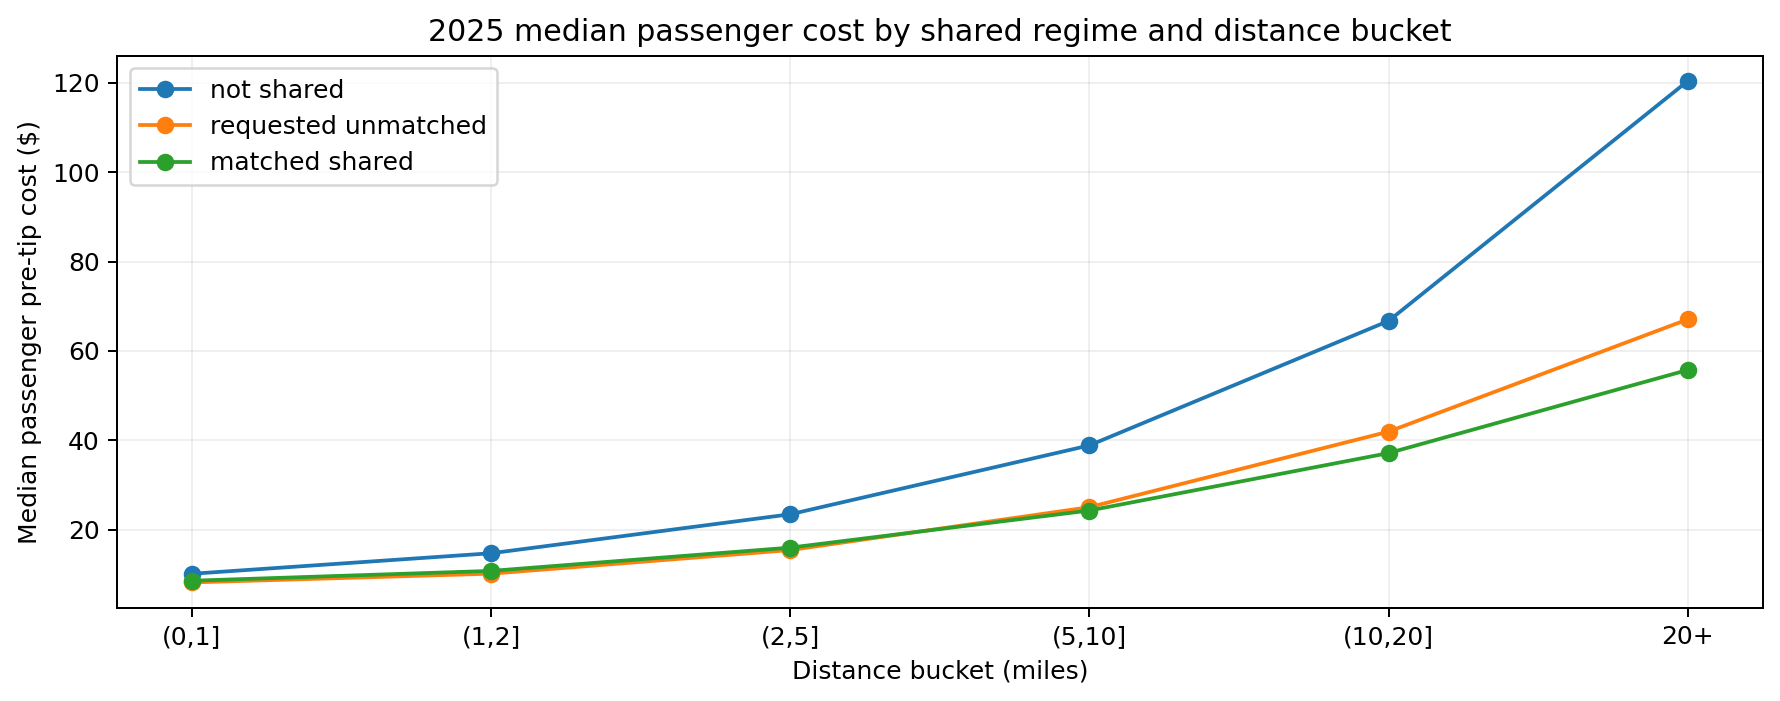

In [12]:
shared_distance_control_2025 = q(
    """
    WITH bucketed AS (
        SELECT
            *,
            CASE
                WHEN shared_request_yes_flag AND shared_match_yes_flag THEN 'matched_shared'
                WHEN shared_request_yes_flag AND NOT shared_match_yes_flag THEN 'requested_unmatched'
                WHEN NOT shared_request_yes_flag AND shared_match_yes_flag THEN 'matched_flag_only'
                ELSE 'not_shared'
            END AS shared_ride_regime,
            CASE
                WHEN trip_distance_miles <= 1 THEN '(0,1]'
                WHEN trip_distance_miles <= 2 THEN '(1,2]'
                WHEN trip_distance_miles <= 5 THEN '(2,5]'
                WHEN trip_distance_miles <= 10 THEN '(5,10]'
                WHEN trip_distance_miles <= 20 THEN '(10,20]'
                ELSE '20+'
            END AS distance_bucket,
            CASE
                WHEN trip_distance_miles <= 1 THEN 1
                WHEN trip_distance_miles <= 2 THEN 2
                WHEN trip_distance_miles <= 5 THEN 3
                WHEN trip_distance_miles <= 10 THEN 4
                WHEN trip_distance_miles <= 20 THEN 5
                ELSE 6
            END AS bucket_order
        FROM trips
        WHERE year = 2025
          AND trip_distance_miles > 0
    ),
    regime_summary AS (
        SELECT
            distance_bucket,
            bucket_order,
            shared_ride_regime,
            COUNT(*) AS rows,
            COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY distance_bucket) AS row_share_within_distance_bucket,
            AVG(CASE WHEN charged_cbd_flag THEN 1.0 ELSE 0.0 END) AS charged_cbd_share,
            MEDIAN(passenger_cost_pretip) AS median_cost,
            MEDIAN(base_passenger_fare) AS median_base_fare,
            MEDIAN(driver_pay) AS median_driver_pay,
            MEDIAN(trip_duration_minutes) AS median_duration_min,
            MEDIAN(CASE WHEN burden_floor1_flag THEN relative_cbd_burden_base_cost ELSE NULL END) AS median_base_cost_burden_floor1
        FROM bucketed
        GROUP BY distance_bucket, bucket_order, shared_ride_regime
    ),
    not_shared AS (
        SELECT
            distance_bucket,
            median_cost AS not_shared_median_cost,
            median_base_fare AS not_shared_median_base_fare,
            median_base_cost_burden_floor1 AS not_shared_median_base_cost_burden_floor1
        FROM regime_summary
        WHERE shared_ride_regime = 'not_shared'
    )
    SELECT
        r.*,
        r.median_cost - n.not_shared_median_cost AS median_cost_gap_vs_not_shared,
        r.median_base_fare - n.not_shared_median_base_fare AS median_base_fare_gap_vs_not_shared,
        r.median_base_cost_burden_floor1 - n.not_shared_median_base_cost_burden_floor1 AS median_burden_gap_vs_not_shared
    FROM regime_summary r
    LEFT JOIN not_shared n USING (distance_bucket)
    ORDER BY
        bucket_order,
        CASE shared_ride_regime
            WHEN 'not_shared' THEN 1
            WHEN 'requested_unmatched' THEN 2
            WHEN 'matched_shared' THEN 3
            ELSE 4
        END
    """
)
display(shared_distance_control_2025)
save_table(shared_distance_control_2025, "hvfhv_full_shared_ride_distance_control_2025.csv")

shared_distance_plot = shared_distance_control_2025[
    shared_distance_control_2025["shared_ride_regime"].isin(
        ["not_shared", "requested_unmatched", "matched_shared"]
    )
].copy()

fig, ax = plt.subplots(figsize=(10, 4))
for regime in ["not_shared", "requested_unmatched", "matched_shared"]:
    g = shared_distance_plot[shared_distance_plot["shared_ride_regime"] == regime].sort_values("bucket_order")
    ax.plot(g["distance_bucket"], g["median_cost"], marker="o", label=regime.replace("_", " "))
ax.set_title("2025 median passenger cost by shared regime and distance bucket")
ax.set_xlabel("Distance bucket (miles)")
ax.set_ylabel("Median passenger pre-tip cost ($)")
ax.grid(alpha=0.2)
ax.legend()
save_figure("hvfhv_full_shared_ride_distance_control_2025.png")
plt.show()


## 7. Day-of-Week Seasonality

This adds day-of-week profiles for volume, passenger cost, driver pay, and charged share. These profiles help separate commute/business patterns from weekend/discretionary travel.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,year,day_of_week,trip_count,median_cost,median_driver_pay,charged_cbd_share
0,2024,0,11938195,22.0200,14.4900,0.0000
1,2024,1,12511921,22.8700,14.7100,0.0000
2,2024,2,13573120,22.9800,15.0400,0.0000
3,2024,3,14857964,23.4500,15.2500,0.0000
4,2024,4,16164191,22.8600,14.8400,0.0000
5,2024,5,17381798,22.9600,14.9600,0.0000
6,2024,6,14765199,22.9600,15.1400,0.0000
7,2025,0,12809533,22.9900,14.8700,0.3302
8,2025,1,12740585,23.6300,15.1000,0.3536
9,2025,2,13670400,23.9600,15.3900,0.3560


Saved table: artifacts/tables/hvfhv_full_day_of_week_summary.csv
Saved figure: artifacts/figures/hvfhv_full_day_of_week_panel.png


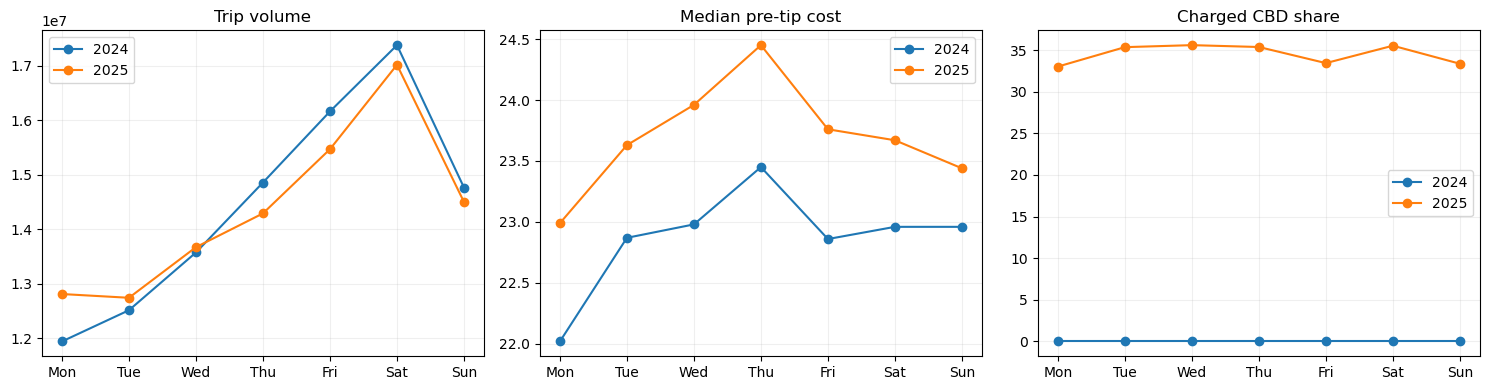

In [13]:
dow = q(
    """
    SELECT
        year,
        day_of_week,
        COUNT(*) AS trip_count,
        MEDIAN(passenger_cost_pretip) AS median_cost,
        MEDIAN(driver_pay) AS median_driver_pay,
        AVG(CASE WHEN charged_cbd_flag THEN 1.0 ELSE 0.0 END) AS charged_cbd_share
    FROM trips
    GROUP BY year, day_of_week
    ORDER BY year, day_of_week
    """
)
labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
display(dow)
save_table(dow, "hvfhv_full_day_of_week_summary.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for year in [2024, 2025]:
    g = dow[dow["year"] == year].sort_values("day_of_week")
    axes[0].plot(g["day_of_week"], g["trip_count"], marker="o", label=str(year))
    axes[1].plot(g["day_of_week"], g["median_cost"], marker="o", label=str(year))
    axes[2].plot(g["day_of_week"], 100 * g["charged_cbd_share"], marker="o", label=str(year))
for ax, title in zip(axes, ["Trip volume", "Median pre-tip cost", "Charged CBD share"]):
    ax.set_title(title)
    ax.set_xticks(range(7))
    ax.set_xticklabels(labels)
    ax.grid(alpha=0.2)
    ax.legend()
save_figure("hvfhv_full_day_of_week_panel.png")
plt.show()

# Part II. Full-Data Validation and Policy Metrics

This block validates sample findings that are not primarily time-series questions and connects the EDA to the project's Zone Disruption Score work.

## 8. Charged Versus Not-Charged Composition

This checks whether the 2025 charged/not-charged differences reflect route composition, cost level, provider/shared-ride mix, and driver-pay differences.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,charged_cbd_flag,rows,median_cost,median_base_fare,median_driver_pay,median_distance,median_duration_min,airport_fee_share,shared_request_share,shared_match_share
0,False,65785711,18.7300,16.4000,13.2500,2.6600,14.1167,0.0764,0.0368,0.0190
1,True,34717751,36.2900,28.1000,20.1800,3.7600,20.3000,0.1020,0.0188,0.0131


Saved table: artifacts/tables/hvfhv_full_charged_comparison_2025.csv
Saved figure: artifacts/figures/hvfhv_full_charged_comparison_2025.png


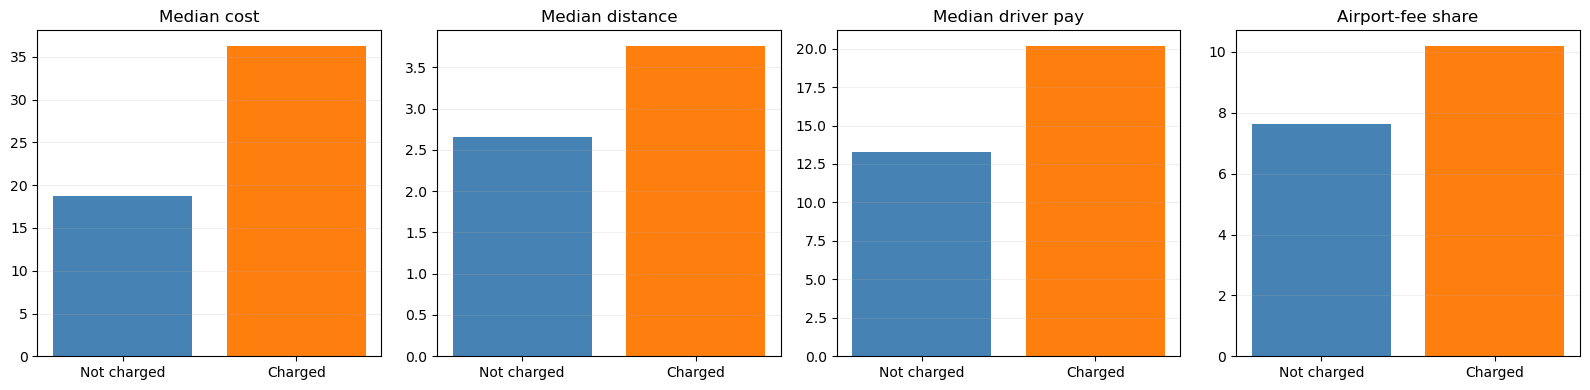

In [14]:
charged_comparison = q(
    """
    SELECT
        charged_cbd_flag,
        COUNT(*) AS rows,
        MEDIAN(passenger_cost_pretip) AS median_cost,
        MEDIAN(base_passenger_fare) AS median_base_fare,
        MEDIAN(driver_pay) AS median_driver_pay,
        MEDIAN(trip_distance_miles) AS median_distance,
        MEDIAN(trip_duration_minutes) AS median_duration_min,
        AVG(CASE WHEN airport_fee_flag THEN 1.0 ELSE 0.0 END) AS airport_fee_share,
        AVG(CASE WHEN shared_request_yes_flag THEN 1.0 ELSE 0.0 END) AS shared_request_share,
        AVG(CASE WHEN shared_match_yes_flag THEN 1.0 ELSE 0.0 END) AS shared_match_share
    FROM trips
    WHERE year = 2025
    GROUP BY charged_cbd_flag
    ORDER BY charged_cbd_flag
    """
)
display(charged_comparison)
save_table(charged_comparison, "hvfhv_full_charged_comparison_2025.csv")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
labels_charged = ["Not charged", "Charged"]
for ax, col, title in [
    (axes[0], "median_cost", "Median cost"),
    (axes[1], "median_distance", "Median distance"),
    (axes[2], "median_driver_pay", "Median driver pay"),
    (axes[3], "airport_fee_share", "Airport-fee share"),
]:
    vals = charged_comparison[col].to_numpy()
    if col.endswith("_share"):
        vals = 100 * vals
    ax.bar(labels_charged, vals, color=["steelblue", "tab:orange"])
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.2)
save_figure("hvfhv_full_charged_comparison_2025.png")
plt.show()

## 9. Burden Distribution and Tail Behavior

HVFHV has two relevant burden definitions:

- `relative_cbd_burden_current_cost`: CBD fee divided by all pre-tip passenger cost.
- `relative_cbd_burden_base_cost`: CBD fee divided by pre-tip passenger cost net of CBD fee, used for DS_z. The primary DS_z rule applies a rounded `$1` base-cost floor.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,definition,rows,mean_burden,p25,median,p75,p90,p95,p99
0,fee/current cost,34717751,0.0458,0.0268,0.0413,0.0606,0.0807,0.0940,0.1155
1,"fee/base cost, floor=$1",34717442,0.0487,0.0275,0.0431,0.0645,0.0878,0.1037,0.1305


Saved table: artifacts/tables/hvfhv_full_burden_quantiles_2025.csv
Saved figure: artifacts/figures/hvfhv_full_burden_quantiles_2025.png


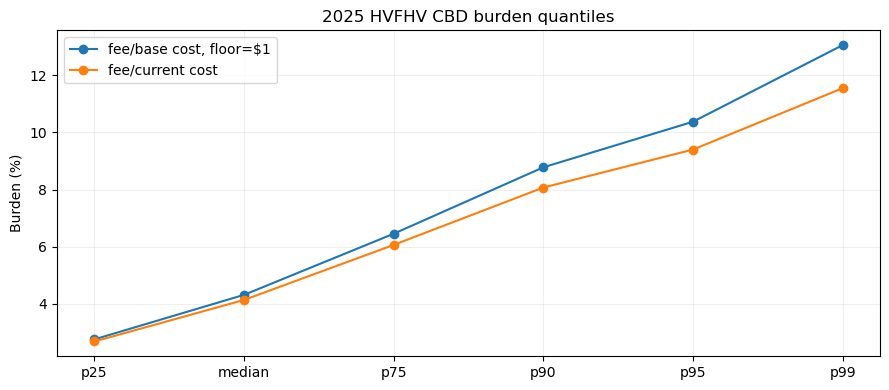

In [15]:
burden_quantiles = q(
    f"""
    SELECT
        'fee/current cost' AS definition,
        COUNT(*) AS rows,
        AVG(relative_cbd_burden_current_cost) AS mean_burden,
        QUANTILE_CONT(relative_cbd_burden_current_cost, 0.25) AS p25,
        MEDIAN(relative_cbd_burden_current_cost) AS median,
        QUANTILE_CONT(relative_cbd_burden_current_cost, 0.75) AS p75,
        QUANTILE_CONT(relative_cbd_burden_current_cost, 0.90) AS p90,
        QUANTILE_CONT(relative_cbd_burden_current_cost, 0.95) AS p95,
        QUANTILE_CONT(relative_cbd_burden_current_cost, 0.99) AS p99
    FROM trips
    WHERE year = 2025
      AND charged_cbd_flag
      AND cbd_congestion_fee > 0
      AND relative_cbd_burden_current_cost IS NOT NULL
    UNION ALL
    SELECT
        'fee/base cost, floor=$1' AS definition,
        COUNT(*) AS rows,
        AVG(relative_cbd_burden_base_cost) AS mean_burden,
        QUANTILE_CONT(relative_cbd_burden_base_cost, 0.25) AS p25,
        MEDIAN(relative_cbd_burden_base_cost) AS median,
        QUANTILE_CONT(relative_cbd_burden_base_cost, 0.75) AS p75,
        QUANTILE_CONT(relative_cbd_burden_base_cost, 0.90) AS p90,
        QUANTILE_CONT(relative_cbd_burden_base_cost, 0.95) AS p95,
        QUANTILE_CONT(relative_cbd_burden_base_cost, 0.99) AS p99
    FROM trips
    WHERE year = 2025
      AND burden_floor1_flag
    """
)
display(burden_quantiles)
save_table(burden_quantiles, "hvfhv_full_burden_quantiles_2025.csv")

plot_quantiles = burden_quantiles.melt(
    id_vars=["definition", "rows", "mean_burden"],
    value_vars=["p25", "median", "p75", "p90", "p95", "p99"],
    var_name="quantile",
    value_name="burden",
)
fig, ax = plt.subplots(figsize=(9, 4))
for definition, g in plot_quantiles.groupby("definition"):
    ax.plot(g["quantile"], 100 * g["burden"], marker="o", label=definition)
ax.set_title("2025 HVFHV CBD burden quantiles")
ax.set_ylabel("Burden (%)")
ax.grid(alpha=0.2)
ax.legend()
save_figure("hvfhv_full_burden_quantiles_2025.png")
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,distance_bucket,bucket_order,rows,charged_cbd_share,median_cost,median_base_cost_burden_floor1,median_driver_pay
0,"(0,1]",1,11107327,0.2497,10.0400,0.0962,5.2300
1,"(1,2]",2,24236191,0.2961,14.4700,0.0714,8.5200
2,"(2,5]",3,33038752,0.3305,22.9900,0.0484,15.3700
3,"(5,10]",4,18908425,0.4175,38.0000,0.0323,26.3600
4,"(10,20]",5,10707468,0.4594,65.4300,0.0195,43.8200
5,20+,6,2493071,0.4137,119.2800,0.0114,76.5600


Saved table: artifacts/tables/hvfhv_full_distance_exposure_2025.csv
Saved figure: artifacts/figures/hvfhv_full_distance_exposure_2025.png


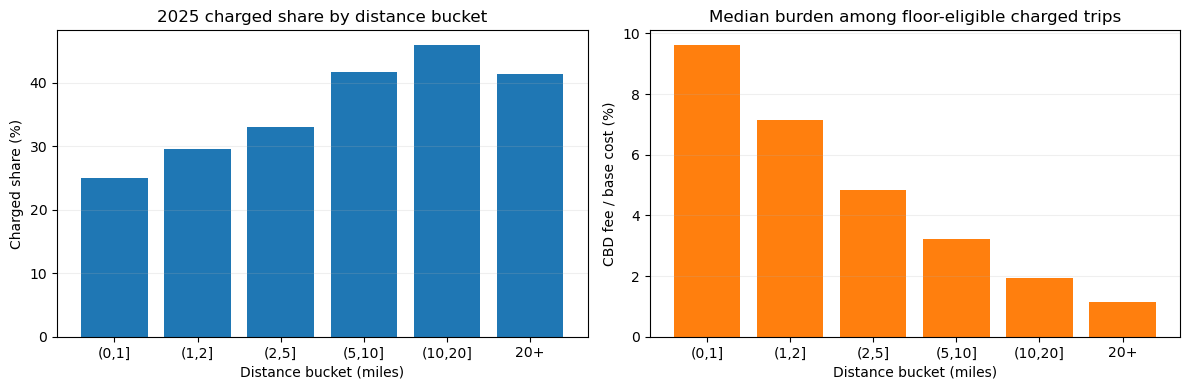

In [16]:
distance_exposure = q(
    """
    WITH bucketed AS (
        SELECT
            *,
            CASE
                WHEN trip_distance_miles <= 1 THEN '(0,1]'
                WHEN trip_distance_miles <= 2 THEN '(1,2]'
                WHEN trip_distance_miles <= 5 THEN '(2,5]'
                WHEN trip_distance_miles <= 10 THEN '(5,10]'
                WHEN trip_distance_miles <= 20 THEN '(10,20]'
                ELSE '20+'
            END AS distance_bucket,
            CASE
                WHEN trip_distance_miles <= 1 THEN 1
                WHEN trip_distance_miles <= 2 THEN 2
                WHEN trip_distance_miles <= 5 THEN 3
                WHEN trip_distance_miles <= 10 THEN 4
                WHEN trip_distance_miles <= 20 THEN 5
                ELSE 6
            END AS bucket_order
        FROM trips
        WHERE year = 2025
          AND trip_distance_miles > 0
    )
    SELECT
        distance_bucket,
        bucket_order,
        COUNT(*) AS rows,
        AVG(CASE WHEN charged_cbd_flag THEN 1.0 ELSE 0.0 END) AS charged_cbd_share,
        MEDIAN(passenger_cost_pretip) AS median_cost,
        MEDIAN(CASE WHEN burden_floor1_flag THEN relative_cbd_burden_base_cost ELSE NULL END) AS median_base_cost_burden_floor1,
        MEDIAN(driver_pay) AS median_driver_pay
    FROM bucketed
    GROUP BY distance_bucket, bucket_order
    ORDER BY bucket_order
    """
)
display(distance_exposure)
save_table(distance_exposure, "hvfhv_full_distance_exposure_2025.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(distance_exposure["distance_bucket"], 100 * distance_exposure["charged_cbd_share"])
axes[0].set_title("2025 charged share by distance bucket")
axes[0].set_ylabel("Charged share (%)")
axes[1].bar(distance_exposure["distance_bucket"], 100 * distance_exposure["median_base_cost_burden_floor1"], color="tab:orange")
axes[1].set_title("Median burden among floor-eligible charged trips")
axes[1].set_ylabel("CBD fee / base cost (%)")
for ax in axes:
    ax.set_xlabel("Distance bucket (miles)")
    ax.grid(axis="y", alpha=0.2)
save_figure("hvfhv_full_distance_exposure_2025.png")
plt.show()

In [17]:
floor_rows = []
for floor in [0.50, 1.00, 2.00, 5.00]:
    frame = q(
        f"""
        WITH charged AS (
            SELECT
                ROUND(passenger_cost_pretip - cbd_congestion_fee, 2) AS base_cost_ex_cbd,
                cbd_congestion_fee / ROUND(passenger_cost_pretip - cbd_congestion_fee, 2) AS fee_burden
            FROM trips
            WHERE year = 2025
              AND charged_cbd_flag
              AND cbd_congestion_fee > 0
              AND passenger_cost_pretip IS NOT NULL
              AND cbd_congestion_fee IS NOT NULL
        )
        SELECT
            {floor:.2f} AS minimum_base_cost,
            COUNT(*) AS eligible_rows,
            AVG(fee_burden) AS mean_burden,
            MEDIAN(fee_burden) AS median_burden,
            QUANTILE_CONT(fee_burden, 0.95) AS p95_burden,
            QUANTILE_CONT(fee_burden, 0.99) AS p99_burden
        FROM charged
        WHERE base_cost_ex_cbd >= {floor:.2f}
        """
    )
    floor_rows.append(frame)

floor_sensitivity_trip_level = pd.concat(floor_rows, ignore_index=True)
total_charged = q(
    """
    SELECT COUNT(*) AS total_charged_rows
    FROM trips
    WHERE year = 2025
      AND charged_cbd_flag
      AND cbd_congestion_fee > 0
    """
)["total_charged_rows"].iloc[0]
floor_sensitivity_trip_level["retained_share"] = floor_sensitivity_trip_level["eligible_rows"] / total_charged
display(floor_sensitivity_trip_level)
save_table(floor_sensitivity_trip_level, "hvfhv_full_trip_level_floor_sensitivity_2025.csv")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,minimum_base_cost,eligible_rows,mean_burden,median_burden,p95_burden,p99_burden,retained_share
0,0.5000,34717487,0.0487,0.0431,0.1037,0.1305,1.0000
1,1.0000,34717442,0.0487,0.0431,0.1037,0.1305,1.0000
2,2.0000,34717339,0.0487,0.0431,0.1037,0.1305,1.0000
3,5.0000,34716839,0.0487,0.0431,0.1037,0.1305,1.0000


Saved table: artifacts/tables/hvfhv_full_trip_level_floor_sensitivity_2025.csv


## 10. Driver-Side Metrics

The project currently emphasizes rider burden and trip patterns. HVFHV also exposes `driver_pay`, so this section gives a first full-data look at whether passenger-cost changes line up with driver-pay changes.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,year,month,rows,median_cost,median_base_fare,median_driver_pay,median_driver_pay_per_mile,median_driver_pay_per_hour
0,2024,2,19352998,21.9100,18.5200,14.4600,4.5889,53.8548
1,2024,3,21279860,22.7600,19.2400,14.5300,4.7188,54.6667
2,2024,4,19732410,22.8600,19.3400,14.7700,4.6627,54.6582
3,2024,5,20704206,23.8000,20.1500,15.4600,4.7477,54.3978
4,2024,6,20122914,23.7500,20.1100,15.4800,4.7030,55.0934
5,2025,2,19338054,22.8000,18.8500,14.3400,4.6509,54.4272
6,2025,3,20477120,24.6900,20.6300,15.2000,4.8196,56.9604
7,2025,4,19741018,22.9900,19.1400,15.1500,4.7753,55.6706
8,2025,5,21090841,23.9700,19.9900,16.1200,4.9405,56.6570
9,2025,6,19856429,23.9500,20.0200,16.0600,4.9050,57.4073


Saved table: artifacts/tables/hvfhv_full_driver_monthly.csv
Saved figure: artifacts/figures/hvfhv_full_driver_monthly.png


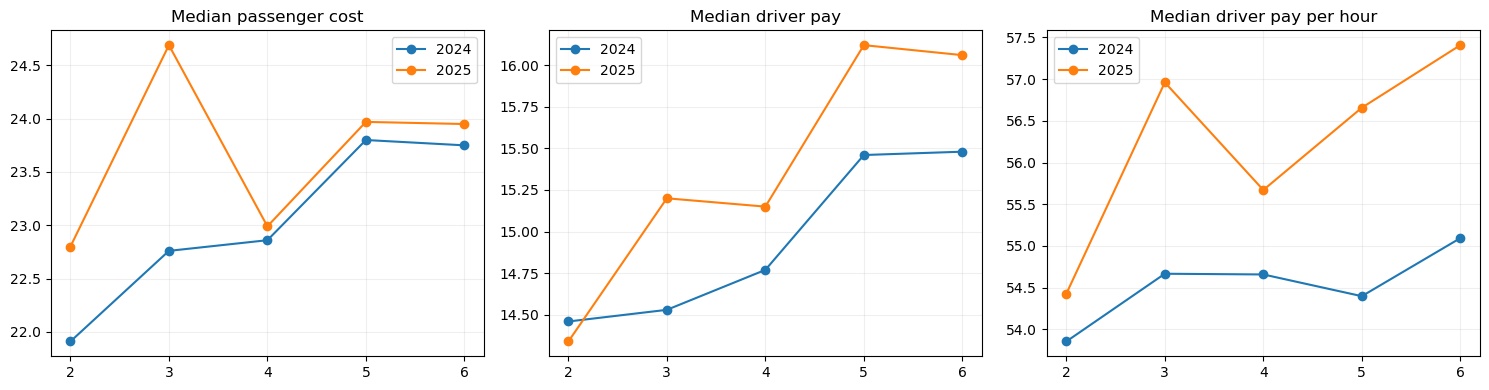

In [18]:
driver_monthly = q(
    """
    SELECT
        year,
        month,
        COUNT(*) AS rows,
        MEDIAN(passenger_cost_pretip) AS median_cost,
        MEDIAN(base_passenger_fare) AS median_base_fare,
        MEDIAN(driver_pay) AS median_driver_pay,
        MEDIAN(driver_pay_per_mile) AS median_driver_pay_per_mile,
        MEDIAN(driver_pay_per_hour) AS median_driver_pay_per_hour
    FROM trips
    WHERE driver_pay IS NOT NULL
    GROUP BY year, month
    ORDER BY year, month
    """
)
display(driver_monthly)
save_table(driver_monthly, "hvfhv_full_driver_monthly.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for year in [2024, 2025]:
    g = driver_monthly[driver_monthly["year"] == year]
    axes[0].plot(g["month"], g["median_cost"], marker="o", label=str(year))
    axes[1].plot(g["month"], g["median_driver_pay"], marker="o", label=str(year))
    axes[2].plot(g["month"], g["median_driver_pay_per_hour"], marker="o", label=str(year))
for ax, title in zip(axes, ["Median passenger cost", "Median driver pay", "Median driver pay per hour"]):
    ax.set_title(title)
    ax.set_xticks([2, 3, 4, 5, 6])
    ax.grid(alpha=0.2)
    ax.legend()
save_figure("hvfhv_full_driver_monthly.png")
plt.show()

In [19]:
driver_provider_2025 = q(
    """
    SELECT
        provider_label,
        charged_cbd_flag,
        COUNT(*) AS rows,
        MEDIAN(passenger_cost_pretip) AS median_cost,
        MEDIAN(base_passenger_fare) AS median_base_fare,
        MEDIAN(driver_pay) AS median_driver_pay,
        MEDIAN(driver_pay_per_mile) AS median_driver_pay_per_mile,
        MEDIAN(driver_pay_per_hour) AS median_driver_pay_per_hour,
        MEDIAN(trip_distance_miles) AS median_distance,
        MEDIAN(trip_duration_minutes) AS median_duration_min
    FROM trips
    WHERE year = 2025
      AND driver_pay IS NOT NULL
    GROUP BY provider_label, charged_cbd_flag
    ORDER BY provider_label, charged_cbd_flag
    """
)
display(driver_provider_2025)
save_table(driver_provider_2025, "hvfhv_full_driver_provider_2025.csv")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,provider_label,charged_cbd_flag,rows,median_cost,median_base_fare,median_driver_pay,median_driver_pay_per_mile,median_driver_pay_per_hour,median_distance,median_duration_min
0,Lyft,False,17916911,18.7100,16.4400,13.0300,4.8041,54.2600,2.6040,14.1667
1,Lyft,True,10056934,31.9400,24.4500,19.3800,4.8148,55.1888,3.8760,20.5000
2,Uber,False,47868800,18.7600,16.3800,13.3400,4.7225,56.2268,2.6900,14.0833
3,Uber,True,24660817,38.4400,29.8600,20.5600,5.1173,58.9867,3.7000,20.2000


Saved table: artifacts/tables/hvfhv_full_driver_provider_2025.csv


## 11. Non-Movement Consistency Check

Yellow Taxi drops zero-distance rows that also have same-zone pickup/dropoff or duration under 60 seconds before the disruption-score/model summaries. HVFHV keeps the full row-level data in the descriptive EDA, but this diagnostic reports how many rows would be affected by the same rule so the final HVFHV model and DS_z sensitivity can stay consistent with Yellow Taxi.


In [20]:
non_movement_check = q(
    """
    WITH flagged AS (
        SELECT
            year,
            charged_cbd_flag,
            shared_request_yes_flag,
            shared_match_yes_flag,
            trip_distance_miles = 0 AS zero_distance_flag,
            trip_distance_miles = 0
                AND (PULocationID = DOLocationID OR trip_duration_seconds < 60)
                AS yellow_rule_non_movement_flag
        FROM trips
    ),
    counts AS (
        SELECT
            year,
            COUNT(*) AS rows,
            SUM(CASE WHEN zero_distance_flag THEN 1 ELSE 0 END) AS zero_distance_rows,
            SUM(CASE WHEN yellow_rule_non_movement_flag THEN 1 ELSE 0 END) AS yellow_rule_non_movement_rows,
            SUM(CASE WHEN charged_cbd_flag AND yellow_rule_non_movement_flag THEN 1 ELSE 0 END) AS charged_non_movement_rows,
            SUM(CASE WHEN shared_request_yes_flag AND yellow_rule_non_movement_flag THEN 1 ELSE 0 END) AS shared_request_non_movement_rows,
            SUM(CASE WHEN shared_match_yes_flag AND yellow_rule_non_movement_flag THEN 1 ELSE 0 END) AS shared_match_non_movement_rows
        FROM flagged
        GROUP BY year
    )
    SELECT
        *,
        zero_distance_rows * 1.0 / rows AS zero_distance_share,
        yellow_rule_non_movement_rows * 1.0 / rows AS yellow_rule_non_movement_share,
        charged_non_movement_rows * 1.0 / rows AS charged_non_movement_share,
        shared_request_non_movement_rows * 1.0 / rows AS shared_request_non_movement_share,
        shared_match_non_movement_rows * 1.0 / rows AS shared_match_non_movement_share
    FROM counts
    ORDER BY year
    """
)
display(non_movement_check)
save_table(non_movement_check, "hvfhv_full_non_movement_check.csv")


,year,rows,zero_distance_rows,yellow_rule_non_movement_rows,charged_non_movement_rows,shared_request_non_movement_rows,shared_match_non_movement_rows,zero_distance_share,yellow_rule_non_movement_share,charged_non_movement_share,shared_request_non_movement_share,shared_match_non_movement_share
0,2024,101192388,"13,698.0000","13,592.0000",0.0000,598.0000,123.0000,0.0001,0.0001,0.0000,0.0000,0.0000
1,2025,100503462,"12,228.0000","12,000.0000","2,194.0000",528.0000,124.0000,0.0001,0.0001,0.0000,0.0000,0.0000


Saved table: artifacts/tables/hvfhv_full_non_movement_check.csv


## 12. Full-Data Geography

This gives stable pickup, dropoff, and OD rankings for 2025 fee-charged HVFHV trips. Unlike DS_z, these rankings are by trip count, so airport corridors can rank highly even with low relative burden.

In [21]:
top_pickups = q(
    """
    SELECT
        z.Borough,
        COALESCE(z.Zone, 'Zone ' || CAST(t.PULocationID AS VARCHAR)) AS Zone,
        t.PULocationID,
        COUNT(*) AS charged_trips,
        MEDIAN(t.relative_cbd_burden_current_cost) AS median_current_cost_burden,
        MEDIAN(CASE WHEN t.burden_floor1_flag THEN t.relative_cbd_burden_base_cost ELSE NULL END) AS median_base_cost_burden_floor1,
        MEDIAN(t.passenger_cost_pretip) AS median_cost,
        MEDIAN(t.driver_pay) AS median_driver_pay
    FROM trips t
    LEFT JOIN zone_lookup z ON t.PULocationID = z.LocationID
    WHERE t.year = 2025
      AND t.charged_cbd_flag
    GROUP BY z.Borough, z.Zone, t.PULocationID
    ORDER BY charged_trips DESC
    LIMIT 15
    """
)

top_dropoffs = q(
    """
    SELECT
        z.Borough,
        COALESCE(z.Zone, 'Zone ' || CAST(t.DOLocationID AS VARCHAR)) AS Zone,
        t.DOLocationID,
        COUNT(*) AS charged_trips,
        MEDIAN(t.relative_cbd_burden_current_cost) AS median_current_cost_burden,
        MEDIAN(CASE WHEN t.burden_floor1_flag THEN t.relative_cbd_burden_base_cost ELSE NULL END) AS median_base_cost_burden_floor1,
        MEDIAN(t.passenger_cost_pretip) AS median_cost,
        MEDIAN(t.driver_pay) AS median_driver_pay
    FROM trips t
    LEFT JOIN zone_lookup z ON t.DOLocationID = z.LocationID
    WHERE t.year = 2025
      AND t.charged_cbd_flag
    GROUP BY z.Borough, z.Zone, t.DOLocationID
    ORDER BY charged_trips DESC
    LIMIT 15
    """
)

top_od = q(
    """
    SELECT
        pu.Borough AS PU_Borough,
        COALESCE(pu.Zone, 'Zone ' || CAST(t.PULocationID AS VARCHAR)) AS PU_Zone,
        t.PULocationID,
        do_z.Borough AS DO_Borough,
        COALESCE(do_z.Zone, 'Zone ' || CAST(t.DOLocationID AS VARCHAR)) AS DO_Zone,
        t.DOLocationID,
        COUNT(*) AS charged_trips,
        MEDIAN(t.relative_cbd_burden_current_cost) AS median_current_cost_burden,
        MEDIAN(CASE WHEN t.burden_floor1_flag THEN t.relative_cbd_burden_base_cost ELSE NULL END) AS median_base_cost_burden_floor1,
        MEDIAN(t.passenger_cost_pretip) AS median_cost,
        MEDIAN(t.driver_pay) AS median_driver_pay
    FROM trips t
    LEFT JOIN zone_lookup pu ON t.PULocationID = pu.LocationID
    LEFT JOIN zone_lookup do_z ON t.DOLocationID = do_z.LocationID
    WHERE t.year = 2025
      AND t.charged_cbd_flag
    GROUP BY
        pu.Borough, pu.Zone, t.PULocationID,
        do_z.Borough, do_z.Zone, t.DOLocationID
    ORDER BY charged_trips DESC
    LIMIT 20
    """
)

display(top_pickups)
display(top_dropoffs)
display(top_od)
save_table(top_pickups, "hvfhv_full_top_pickups_charged_2025.csv")
save_table(top_dropoffs, "hvfhv_full_top_dropoffs_charged_2025.csv")
save_table(top_od, "hvfhv_full_top_od_charged_2025.csv")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Borough,Zone,PULocationID,charged_trips,median_current_cost_burden,median_base_cost_burden_floor1,median_cost,median_driver_pay
0,Manhattan,East Village,79,1205371,0.0505,0.0532,29.6800,16.0000
1,Manhattan,Times Sq/Theatre District,230,1182593,0.0374,0.0388,40.1200,21.1500
2,Manhattan,Midtown Center,161,1160951,0.0395,0.0411,37.9900,19.2500
3,Manhattan,TriBeCa/Civic Center,231,1101516,0.0443,0.0464,33.8400,17.8000
4,Manhattan,East Chelsea,68,1039935,0.0433,0.0453,34.6100,18.2700
5,Manhattan,Union Sq,234,1035755,0.0463,0.0485,32.4300,16.4200
6,Manhattan,West Chelsea/Hudson Yards,246,1008402,0.0458,0.0480,32.7300,16.8900
7,Manhattan,Lower East Side,148,994196,0.0477,0.0501,31.4400,17.1700
8,Manhattan,Midtown South,164,982559,0.0430,0.0450,34.8500,18.0000
9,Manhattan,Clinton East,48,950467,0.0457,0.0479,32.7900,18.4000


,Borough,Zone,DOLocationID,charged_trips,median_current_cost_burden,median_base_cost_burden_floor1,median_cost,median_driver_pay
0,N/A,Outside of NYC,265,1865286,0.0178,0.0181,84.2900,48.6700
1,Manhattan,Midtown Center,161,1029588,0.0458,0.0480,32.7400,16.6200
2,Manhattan,East Chelsea,68,1018399,0.0487,0.0512,30.7800,15.7900
3,Manhattan,Times Sq/Theatre District,230,1010334,0.0424,0.0443,35.3900,18.6100
4,Queens,LaGuardia Airport,138,999642,0.0204,0.0208,73.5300,36.0500
5,Manhattan,East Village,79,983607,0.0546,0.0578,27.4500,14.4700
6,Manhattan,West Chelsea/Hudson Yards,246,946576,0.0505,0.0532,29.6800,15.1400
7,Manhattan,TriBeCa/Civic Center,231,924437,0.0478,0.0502,31.4000,16.2000
8,Manhattan,Union Sq,234,915574,0.0511,0.0538,29.3700,14.6100
9,Manhattan,Murray Hill,170,848198,0.0527,0.0556,28.4900,14.5800


,PU_Borough,PU_Zone,PULocationID,DO_Borough,DO_Zone,DOLocationID,charged_trips,median_current_cost_burden,median_base_cost_burden_floor1,median_cost,median_driver_pay
0,Manhattan,Times Sq/Theatre District,230,N/A,Outside of NYC,265,115095,0.0168,0.0171,89.1500,48.8900
1,Manhattan,Midtown Center,161,N/A,Outside of NYC,265,98613,0.0141,0.0143,106.4000,57.5000
2,Queens,LaGuardia Airport,138,Manhattan,Times Sq/Theatre District,230,90573,0.0179,0.0183,83.5700,41.2300
3,Manhattan,Times Sq/Theatre District,230,Queens,LaGuardia Airport,138,85981,0.0186,0.0189,80.7900,38.8700
4,Manhattan,Clinton East,48,N/A,Outside of NYC,265,81333,0.0230,0.0236,65.1000,35.9600
5,Manhattan,East Chelsea,68,N/A,Outside of NYC,265,78825,0.0196,0.0200,76.4600,41.8600
6,Manhattan,Midtown South,164,N/A,Outside of NYC,265,70948,0.0183,0.0187,81.7500,45.8400
7,Manhattan,West Chelsea/Hudson Yards,246,N/A,Outside of NYC,265,65552,0.0193,0.0197,77.5700,41.7200
8,Manhattan,Union Sq,234,N/A,Outside of NYC,265,63027,0.0176,0.0179,85.4200,48.1300
9,Manhattan,Midtown Center,161,Queens,LaGuardia Airport,138,59515,0.0182,0.0186,82.2400,38.5500


Saved table: artifacts/tables/hvfhv_full_top_pickups_charged_2025.csv
Saved table: artifacts/tables/hvfhv_full_top_dropoffs_charged_2025.csv
Saved table: artifacts/tables/hvfhv_full_top_od_charged_2025.csv


## 13. Zone Disruption Score Outputs

This section reads the existing full-data DS_z exports produced by `scripts/01_pipeline.py`. These files are the authoritative project outputs for the DS_z formula and floor-sensitivity checks.

,denominator_floor,zone,direction,Borough,zone_name,service_zone,N_z,DS_z,DS_z_median,DS_z_rank,DS_z_median_rank
0,1.0000,4,dropoff,Manhattan,Alphabet City,Yellow Zone,239356,0.0638,0.0593,1,2
1,1.0000,224,dropoff,Manhattan,Stuy Town/Peter Cooper Village,Yellow Zone,160441,0.0631,0.0594,2,1
2,1.0000,79,dropoff,Manhattan,East Village,Yellow Zone,983593,0.0625,0.0578,3,4
3,1.0000,249,dropoff,Manhattan,West Village,Yellow Zone,742528,0.0619,0.0588,4,3
4,1.0000,114,dropoff,Manhattan,Greenwich Village South,Yellow Zone,526218,0.0617,0.0576,5,5
5,1.0000,137,dropoff,Manhattan,Kips Bay,Yellow Zone,499679,0.0615,0.0569,6,7
6,1.0000,232,dropoff,Manhattan,Two Bridges/Seward Park,Yellow Zone,353805,0.0614,0.0566,7,9
7,1.0000,113,dropoff,Manhattan,Greenwich Village North,Yellow Zone,492654,0.0614,0.0571,8,6
8,1.0000,107,dropoff,Manhattan,Gramercy,Yellow Zone,628489,0.0610,0.0566,9,8
9,1.0000,45,dropoff,Manhattan,Chinatown,Yellow Zone,212931,0.0605,0.0550,10,13


,zone,direction,Borough,zone_name,service_zone,DS_z,DS_z_median,N_z,DS_z_rank,pct_volume_change,n_2024,n_2025,low_n_flag,avg_total_cost_2024,avg_total_cost_2025,avg_base_fare_2024,avg_base_fare_2025
0,4,dropoff,Manhattan,Alphabet City,Yellow Zone,0.0638,0.0593,239356,1,-0.1082,"271,542.0000",242158,False,27.5567,30.6622,21.9669,23.4229
1,224,dropoff,Manhattan,Stuy Town/Peter Cooper Village,Yellow Zone,0.0631,0.0594,160441,2,-0.1261,"187,122.0000",163517,False,28.5920,32.0892,22.3762,24.1777
2,79,dropoff,Manhattan,East Village,Yellow Zone,0.0625,0.0578,983593,3,-0.1147,"1,119,252.0000",990843,False,28.1943,31.8572,22.3753,24.4055
3,249,dropoff,Manhattan,West Village,Yellow Zone,0.0619,0.0588,742528,4,-0.0935,"824,488.0000",747373,False,28.7686,32.4988,22.9187,25.0237
4,114,dropoff,Manhattan,Greenwich Village South,Yellow Zone,0.0617,0.0576,526218,5,-0.1017,"589,097.0000",529171,False,28.6600,32.3426,22.9214,24.9832
5,137,dropoff,Manhattan,Kips Bay,Yellow Zone,0.0615,0.0569,499679,6,-0.0777,"552,594.0000",509670,False,29.2585,32.7486,22.5839,24.3349
6,232,dropoff,Manhattan,Two Bridges/Seward Park,Yellow Zone,0.0614,0.0566,353805,7,-0.0993,"400,060.0000",360354,False,29.3838,32.1839,23.6188,24.8580
7,113,dropoff,Manhattan,Greenwich Village North,Yellow Zone,0.0614,0.0571,492654,8,-0.0975,"549,348.0000",495763,False,29.4741,33.5344,23.3956,25.7690
8,107,dropoff,Manhattan,Gramercy,Yellow Zone,0.0610,0.0566,628489,9,-0.1030,"706,153.0000",633416,False,29.5345,33.6747,23.0690,25.4812
9,45,dropoff,Manhattan,Chinatown,Yellow Zone,0.0605,0.0550,212931,10,-0.0412,"223,679.0000",214468,False,30.5053,33.3918,24.5916,25.9223


Pearson correlation, DS_z vs pct volume change: -0.610 (n=519)
Saved figure: artifacts/figures/hvfhv_full_dsz_outputs_summary.png


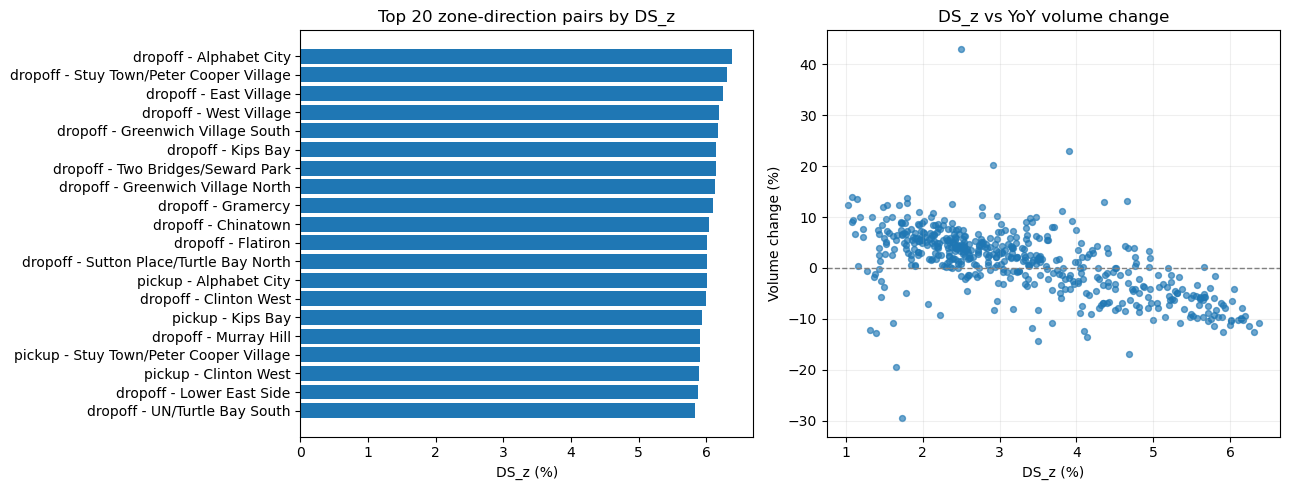

In [22]:
ds_path = DISRUPTION_DIR / "hvfhv_zone_disruption_score.csv"
joined_path = DISRUPTION_DIR / "hvfhv_ds_z_vs_volume_change.csv"
rank_path = DISRUPTION_DIR / "hvfhv_ds_rank_stability.csv"
borough_path = DISRUPTION_DIR / "hvfhv_borough_correlation.csv"
manhattan_path = DISRUPTION_DIR / "hvfhv_within_manhattan_correlation.csv"

missing_outputs = [p for p in [ds_path, joined_path] if not p.exists()]
if missing_outputs:
    print("Missing DS_z output files:")
    for path in missing_outputs:
        print(f"  - {path.relative_to(REPO_ROOT)}")
    print("Run: python scripts/01_pipeline.py")
else:
    ds = pd.read_csv(ds_path)
    joined = pd.read_csv(joined_path)
    display(ds.head(20))
    display(joined.head(20))

    usable = joined[~joined["low_n_flag"] & joined["pct_volume_change"].notna()].copy()
    corr = usable["DS_z"].corr(usable["pct_volume_change"])
    print(f"Pearson correlation, DS_z vs pct volume change: {corr:.3f} (n={len(usable):,})")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    top = ds.sort_values("DS_z", ascending=False).head(20).copy()
    axes[0].barh(
        top["direction"] + " - " + top["zone_name"],
        100 * top["DS_z"],
    )
    axes[0].invert_yaxis()
    axes[0].set_title("Top 20 zone-direction pairs by DS_z")
    axes[0].set_xlabel("DS_z (%)")

    axes[1].scatter(100 * usable["DS_z"], 100 * usable["pct_volume_change"], s=18, alpha=0.65)
    axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[1].set_title("DS_z vs YoY volume change")
    axes[1].set_xlabel("DS_z (%)")
    axes[1].set_ylabel("Volume change (%)")
    axes[1].grid(alpha=0.2)
    save_figure("hvfhv_full_dsz_outputs_summary.png")
    plt.show()

In [23]:
if "joined" in globals():
    quartile_data = joined[~joined["low_n_flag"] & joined["pct_volume_change"].notna()].copy()
    quartile_data["ds_quartile"] = quartile_data.groupby("direction")["DS_z"].transform(
        lambda s: pd.qcut(s, 4, labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"])
    )
    quartiles = (
        quartile_data.groupby(["direction", "ds_quartile"], observed=False)
        .agg(
            n_pairs=("zone", "size"),
            avg_DS_z=("DS_z", "mean"),
            avg_pct_volume_change=("pct_volume_change", "mean"),
            median_pct_volume_change=("pct_volume_change", "median"),
        )
        .reset_index()
    )
    display(quartiles)
    save_table(quartiles, "hvfhv_full_dsz_volume_quartiles.csv")

    if rank_path.exists():
        rank_stability = pd.read_csv(rank_path)
        display(rank_stability)
    if borough_path.exists():
        borough_corr = pd.read_csv(borough_path)
        display(borough_corr)
    if manhattan_path.exists():
        manhattan_corr = pd.read_csv(manhattan_path)
        display(manhattan_corr)

,direction,ds_quartile,n_pairs,avg_DS_z,avg_pct_volume_change,median_pct_volume_change
0,dropoff,Q1 lowest,65,0.0176,0.0441,0.0559
1,dropoff,Q2,65,0.0263,0.0311,0.0353
2,dropoff,Q3,65,0.0360,0.0117,0.0176
3,dropoff,Q4 highest,65,0.0532,-0.0534,-0.0615
4,pickup,Q1 lowest,65,0.0181,0.0465,0.0575
5,pickup,Q2,65,0.0255,0.0452,0.0417
6,pickup,Q3,64,0.0347,0.0117,0.0149
7,pickup,Q4 highest,65,0.0500,-0.0484,-0.0528


Saved table: artifacts/tables/hvfhv_full_dsz_volume_quartiles.csv


,definition_key,denominator_floor,aggregation_method,direction,n_zone_direction_pairs,spearman_rank_corr_vs_primary,mean_abs_rank_delta,median_abs_rank_delta,max_abs_rank_delta
0,floor_0_50_mean,0.5000,mean,all,525,1.0000,0.0038,0.0000,1
1,floor_0_50_mean,0.5000,mean,dropoff,263,1.0000,0.0076,0.0000,1
2,floor_0_50_mean,0.5000,mean,pickup,262,1.0000,0.0000,0.0000,0
3,floor_1_00_mean,1.0000,mean,all,525,1.0000,0.0000,0.0000,0
4,floor_1_00_mean,1.0000,mean,dropoff,263,1.0000,0.0000,0.0000,0
5,floor_1_00_mean,1.0000,mean,pickup,262,1.0000,0.0000,0.0000,0
6,floor_2_00_mean,2.0000,mean,all,525,1.0000,0.0152,0.0000,4
7,floor_2_00_mean,2.0000,mean,dropoff,263,1.0000,0.0000,0.0000,0
8,floor_2_00_mean,2.0000,mean,pickup,262,1.0000,0.0305,0.0000,4
9,floor_5_00_mean,5.0000,mean,all,525,1.0000,0.0648,0.0000,9


,group_type,group_name,borough,direction,n_rows,pearson_corr,spearman_corr,sufficient_n
0,all_zones,all zones,NaN,NaN,524,-0.5247,-0.6329,True
1,manhattan_split,Manhattan only,Manhattan,NaN,135,-0.5397,-0.5264,True
2,manhattan_split,non-Manhattan only,NaN,NaN,389,-0.2272,-0.3504,True
3,borough,Bronx,Bronx,NaN,85,-0.0923,-0.2761,True
4,borough,Brooklyn,Brooklyn,NaN,122,-0.1654,-0.3668,True
5,borough,EWR,EWR,NaN,2,NaN,NaN,False
6,borough,Manhattan,Manhattan,NaN,135,-0.5397,-0.5264,True
7,borough,Queens,Queens,NaN,138,0.0639,-0.1136,True
8,borough,Staten Island,Staten Island,NaN,40,-0.2317,-0.2435,True
9,borough,Missing Borough,Missing Borough,NaN,2,NaN,NaN,False


,group_type,group_name,borough,direction,n_rows,pearson_corr,spearman_corr,sufficient_n
0,manhattan_split,Manhattan only,Manhattan,NaN,135,-0.5397,-0.5264,True
1,borough,Manhattan,Manhattan,NaN,135,-0.5397,-0.5264,True
2,borough_direction,Manhattan dropoff,Manhattan,dropoff,68,-0.5502,-0.5244,True
3,borough_direction,Manhattan pickup,Manhattan,pickup,67,-0.5599,-0.5350,True


## 14. Summary

This full-data EDA uses the standardized HVFHV records for February-June 2024 and February-June 2025. It documents volume, cost, CBD-exposure, shared-ride, and zone-level burden patterns, then connects those patterns to the disruption-score outputs used downstream.

### Main takeaways

**Coverage and volume.** The run covers 10 standardized parquet files: 101.2M trips in 2024 and 100.5M trips in 2025, for an overall volume change of -0.7%. The monthly pattern is uneven: March fell -3.8%, May rose +1.9%, and the other matched months moved more modestly. Provider mix also shifted, with Uber declining from 74.5% to 72.2% of trips and Lyft rising from 25.5% to 27.8%.

**Costs and driver-side metrics.** Median passenger pre-tip cost rose in every matched month, from +USD 0.13 in April to +USD 1.93 in March. Base fare increased only in February and March, while median driver pay fell slightly in February and rose from March through June. Driver pay therefore does not simply mirror base fare: median driver pay per mile and per hour are higher in every matched 2025 month, even when base fare is lower from April through June.

**Seasonality and timing.** Trip volume has strong weekly structure, with lag-7 correlations of 0.825 in 2024 and 0.860 in 2025, both well above lag-1. Median cost and driver pay are more persistent day to day than weekly-seasonal. In 2025, 34.7M trips were charged the CBD fee, about 34.5% of trips. Hourly exposure peaks at 9 PM at 40.3% and is lowest at 7 AM at 27.6%; median base-cost burden is highest around 7 PM at 4.76%.

**Charged trips and burden.** Charged trips are longer and more expensive than non-charged trips, with median passenger cost USD 36.29 versus USD 18.73, driver pay USD 20.18 versus USD 13.25, distance 3.76 versus 2.66 miles, and airport-fee share 10.2% versus 7.6%. Among charged 2025 trips, median fee/current-cost burden is 4.13%; the USD 1 base-cost-floor definition gives median burden 4.31%, p95 10.37%, and p99 13.05%. The USD 0.50, USD 1, USD 2, and USD 5 floor sensitivity is stable and retains more than 99.997% of charged trips.

**Distance pattern.** Shorter trips carry the highest relative burden: 0-1 mile trips have 9.62% median base-cost burden. Longer trips have higher CBD exposure through the 10-20 mile bucket, but much lower relative burden.

**Shared rides.** Shared trips remain in the main rider-level burden summaries, but they should be treated as a sensitivity issue for vehicle-volume interpretation. In 2025, shared requests are 3.06% of rows and matched shared trips are 1.69%. Within every distance bucket, requested-unmatched and matched-shared rides have lower median passenger cost than non-shared rides, so their relative CBD burden is higher. Matched shared rows are at most 3.32% of any distance bucket, which supports a sensitivity check rather than a full rebuild of the EDA.

**Non-movement consistency.** The Yellow-style non-movement rule, `trip_distance_miles = 0` and either same pickup/dropoff zone or duration under 60 seconds, flags 13,592 rows in 2024 and 12,000 rows in 2025, about 0.01% of each year. Only 2,194 charged 2025 rows are affected. Applying this drop in HVFHV DS_z/model sensitivity would improve consistency with Yellow Taxi without materially changing the EDA conclusions.

**Geography and OD patterns.** Top charged pickups are concentrated in core Manhattan zones, led by East Village, Times Sq/Theatre District, and Midtown Center. The largest charged dropoff total is Outside of NYC, and the largest charged OD corridor is Times Sq/Theatre District to Outside of NYC.

**DS_z relationship.** In this notebook, `DS_z` follows the current disruption-score CSV column: the mean fee/base-cost burden with the USD 1 denominator floor; `DS_z_median` is retained as a companion robustness measure. Higher-DS_z zones show lower volume growth. In the low-N-filtered joined table, `DS_z` versus percent volume change has Pearson correlation -0.610 (n=519); the highest `DS_z` quartile averages -5.3% volume change for dropoffs and -4.8% for pickups. The negative relationship also appears in robustness summaries, including all-zone Spearman -0.633, Manhattan-only Pearson -0.540, Manhattan dropoff Pearson -0.550, and Manhattan pickup Pearson -0.560.

### Interpretation notes

These results are descriptive rather than causal. The EDA shows that CBD fee burden is uneven across times, distances, zones, and providers, and that higher-burden zone-sides tend to have weaker volume growth. The notebook should be read alongside the modeling and placebo checks before making a policy-effect claim.
